# Pre-Field Induced Exchange Bias 
**Device:** FGT-OFGT-CrPS4


**Structure:** the analysis backbone follows `EB due to Prefield complete.py` (single load of all PF data, split by HEB sign). Dedicated subsections then plot the PF +1T and PF −1T subsets individually before the combined summary.


In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, str(Path().resolve().parent))
from scripts.data_loader import (
    load_h5, load_txt, get_file_list,
    offset_and_AHE, normalize,
    coercivity_zero_crossing, exchange_bias, coercive_width,
    sort_serial, fixjump,
)
from scripts.notebook_setup import setup
setup()

PROJECT_ROOT = Path().resolve().parent
D2 = PROJECT_ROOT / 'data' / 'Device2'


# â”€â”€ shared: load folder, run analysis, produce per-file diagnostics â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def analyse_folder(folder, skiprows=15, vxy_col='Voltage-2 (V)',
                   channel_xy=2, P=1, fixjump_threshold=None,
                   fixjump_guessindex=None):
    """
    Load all .h5/.txt files, run coercivity analysis, plot per-file diagnostics.
    Returns a dict of arrays keyed by T for each observable.
    """
    T_g, H1_g, H2_g = [], [], []
    Field_g, Vxy_g, Vxy_err_g, Vxx_g, Vxx_err_g = [], [], [], [], []
    Vxy_norm_g, Vahe_g, Vahe_err_g, R_g = [], [], [], []

    for fp in get_file_list(folder):
        if fp.suffix.lower() == '.h5':
            d = load_h5(fp, channel_xy=channel_xy, P=P)
        else:
            d = load_txt(fp, skiprows=skiprows, vxy_col=vxy_col, trim='head')
        F = d['Field'];  Sig = d['Vxy'].copy();  ref = d['Vxx']
        Serr = d['Vxy_err'];  Rerr = d['Vxx_err'];  T = d['T']

        if fp.name.endswith('fix.txt') and fixjump_threshold is not None:
            Sig = fixjump(Sig, fixjump_threshold)
        if fp.suffix.lower() == '.h5' and T == 30 and fixjump_threshold is not None:
            Sig = fixjump(Sig, fixjump_threshold, guessindex=fixjump_guessindex)

        offset, _, Vahe, Vahe_err = offset_and_AHE(Sig)
        Sig_norm = normalize(Sig, offset, Vahe)
        HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
        HEB = exchange_bias(HC_neg, HC_pos)

        peak = np.max(ref);  idx = np.abs(ref - peak) < 0.5
        R_g.append(np.mean(ref[idx]) if idx.any() else peak)

        T_g.append(T);  H1_g.append(HC_neg);  H2_g.append(HC_pos)
        Field_g.append(F);  Vxy_g.append(Sig);  Vxy_err_g.append(Serr)
        Vxx_g.append(ref);  Vxx_err_g.append(Rerr)
        Vxy_norm_g.append(Sig_norm)
        Vahe_g.append(float(Vahe));  Vahe_err_g.append(float(Vahe_err))

        # F1 per file: Vxy
        #plt.figure()
        #plt.xlabel('Magnetic Field (mT)');  plt.ylabel('Vxy (uV)')
        #plt.title(f'T = {T} K  EB = {HEB:.1f} mT')
        #plt.plot(F, Sig);  plt.errorbar(F, Sig, Serr, fmt='o')
        #plt.tight_layout();  plt.show()

        # F2 per file: Vxx
        #plt.figure()
        #plt.xlabel('Magnetic Field (mT)');  plt.ylabel('Vxx (uV)')
        #plt.title(f'T = {T} K  EB = {HEB:.1f} mT')
        #plt.plot(F, ref);  plt.errorbar(F, ref, Rerr, fmt='o')
        #plt.tight_layout();  plt.show()

    T_arr   = np.array(T_g)
    H1_arr  = np.array(H1_g);  H2_arr = np.array(H2_g)
    W_arr   = np.abs(H1_arr - H2_arr) / 2
    HEB_arr = (H1_arr + H2_arr) / 2
    sortT   = np.sort(T_arr)
    sortHEB = sort_serial(list(T_arr), list(HEB_arr))
    sortW   = sort_serial(list(T_arr), list(W_arr))

    return dict(
        T_g=T_arr, H1_g=H1_arr, H2_g=H2_arr,
        W=W_arr, HEB=HEB_arr,
        sorted_T=sortT, sorted_HEB=sortHEB, sorted_W=sortW,
        Field_g=Field_g, Vxy_g=Vxy_g, Vxy_err_g=Vxy_err_g,
        Vxx_g=Vxx_g, Vxx_err_g=Vxx_err_g,
        Vxy_norm_g=Vxy_norm_g,
        Vahe_g=np.array(Vahe_g), Vahe_err_g=np.array(Vahe_err_g),
        R_g=np.array(R_g),
    )


def index_of(T_g, T):
    for i, t in enumerate(T_g):
        if t == T:
            return i
    return None


def heb_hc_summary(res):
    """F3 + F4: HEB vs T and HC vs T errorbars."""
    plt.figure(dpi=600)
    plt.errorbar(res['sorted_T'], res['sorted_HEB'], 2.5, fmt='-o', ecolor='m', markersize=10)
    plt.xlabel('Temperature (K)', fontsize=18);  plt.ylabel('$H_{EB}$ (mT)', fontsize=18)
    plt.tight_layout();  plt.show()

    plt.figure(dpi=600)
    plt.errorbar(res['sorted_T'], res['sorted_W'], 2.5, fmt='-o', ecolor='m', markersize=10)
    plt.xlabel('Temperature (K)', fontsize=18);  plt.ylabel('$H_C$ (mT)', fontsize=18)
    plt.tight_layout();  plt.show()


def waterfall_stack(res, groups, dashed_xlim=None):
    """
    Draw waterfall figure for a list of temperature groups.
    groups: list of (T, offset) pairs. Sign flip applied automatically
    if flip_temps set is passed.
    dashed_xlim: (ylo, yhi) for the dashed B=0 vertical line.
    """
    plt.figure(dpi=600)
    labels = []
    for T_val, off, flip in groups:
        i = index_of(res['T_g'], T_val)
        if i is None:
            print(f'[WARNING] T={T_val} K not found');  continue
        sig = (-1 * res['Vxy_norm_g'][i]) if flip else res['Vxy_norm_g'][i]
        plt.errorbar(res['Field_g'][i], sig + off, res['Vxy_err_g'][i], fmt='-', markersize=1,label=f'{T_val} K')
        plt.plot([res['HEB'][i], res['HEB'][i]], [off + 1.1, off + 1.1 - 2.2], '-')
        plt.arrow(0, off, res['HEB'][i], 0, head_width=0.3, head_length=10,
                  length_includes_head=True)
    if dashed_xlim:
        plt.plot([0, 0], list(dashed_xlim), '--', color='k')
    plt.legend( loc='lower right', fontsize=15)
    plt.xlabel('Magnetic Field (mT)', fontsize=20);  plt.ylabel('Vxy (norm.)', fontsize=20)
    plt.xticks([-400, -200, 0, 200, 400], fontsize=15);  plt.yticks([])
    plt.xlim(-450, 450)
    plt.tight_layout();  plt.show()


def load_selected_pf(folder, skiprows=16, vxy_col='Voltage-1(V)', P=1, channel_xy=2):
    """Load selected-plot files and return T_g, Field_g, Vxy_norm_g, Vxy_err_g."""
    T_g, Field_g, Vxy_norm_g, Vxy_err_g = [], [], [], []
    for fp in get_file_list(folder):
        if fp.suffix.lower() == '.h5':
            d = load_h5(fp, channel_xy=channel_xy, P=P)
        else:
            d = load_txt(fp, skiprows=skiprows, vxy_col=vxy_col, trim='tail')
        F = d['Field'];  Sig = d['Vxy'];  Serr = d['Vxy_err'];  T = d['T']
        offset, _, Vahe, _ = offset_and_AHE(Sig)
        Sig_norm = normalize(Sig, offset, Vahe)
        HC_neg, HC_pos = coercivity_zero_crossing(F, Sig_norm)
        HEB = exchange_bias(HC_neg, HC_pos)
        T_g.append(T);  Field_g.append(F)
        Vxy_norm_g.append(Sig_norm);  Vxy_err_g.append(Serr)
        plt.figure()
        plt.xlabel('Magnetic Field (mT)');  plt.ylabel('Vxy (uV)')
        plt.title(f'T = {T} K  H_EB = {HEB:.1f} mT')
        plt.errorbar(F, Sig, Serr, fmt='o')
        plt.tight_layout();  plt.show()
    return T_g, Field_g, Vxy_norm_g, Vxy_err_g


def waterfall_selected(T_g, Field_g, Vxy_norm_g, Vxy_err_g, specs):
    """Highlight waterfall for 3 temperatures (figsize 4Ã—6.7)."""
    plt.figure(figsize=(4, 6.7))
    plt.xlabel('Magnetic Field (mT)', fontsize=15);  plt.ylabel('Vxy (norm.)', fontsize=15)
    for sp in specs:
        i = next((k for k, t in enumerate(T_g) if t == sp['T']), None)
        if i is None:
            print(f'[WARNING] T={sp["T"]} K not found');  continue
        sig = (-1 * Vxy_norm_g[i]) if sp.get('flip') else Vxy_norm_g[i]
        err = Vxy_err_g[i] * sp.get('err_scale', 1.0)
        kw  = {'color': sp['color']} if 'color' in sp else {}
        plt.errorbar(Field_g[i], sig + sp['offset'], err, fmt='-o', markersize=6, **kw)
    plt.legend([s['label'] for s in specs], fontsize=15)
    plt.ylim(-3.5, 3.5)
    plt.tight_layout();  plt.show()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
[OK] Autoreload enabled
[OK] Project root (installed package): C:\Users\sadit\OneDrive - JGU\Projects\EB in FGT-OFGT_CrPS4
[OK] Matplotlib configured (Okabe-Ito palette, publication style)
Setup complete!


---
##  Complete Dataset — Loading 

Both PF +1T and PF −1T measurements are loaded here in a single pass.
`posEB` (HEB > 0) indexes the **PF −1T** files; `negEB` (HEB < 0) indexes the **PF +1T** files.
Hardcoded FC 8T and OFGT comparison arrays are defined here for use in later summary plots.

In [4]:
FOLDER_PF_COMPLETE = D2 / 'With_prefield' / 'Pre_field_data_remeasured'
res_pf = analyse_folder(FOLDER_PF_COMPLETE, skiprows=15, vxy_col='Voltage-2 (V)',
                        fixjump_threshold=0.5)

posEB = np.where(res_pf['HEB'] > 0)[0]
negEB = np.where(res_pf['HEB'] < 0)[0]

# â”€â”€ Hardcoded comparison data (FC 8T from 290K and OFGT pre-field) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
TFC   = [25, 40, 10, 5, 150, 15, 20, 30, 100, 60, 70, 80, 130]
EBFC  = [-38.85, -47.73, -12.70, -35.48, -0.61, -0.27, -10.41, -50.00,
         -30.33, -32.66, -20.14, -63.78, -9.0]
WFC   = [230.91, 234.51, 287.88, 292.98, 11.37, 290.10, 260.12, 240.71,
         52.70, 208.71, 196.10, 90.87, 20.0]
errFC = [9.87, 4.72, 2.53, 2.53, 10.00, 10.00, 10.00, 10.00,
         2.51, 2.51, 2.51, 2.51, 2.5]
T_OFGT = [10, 20, 30, 40, 50, 50, 60, 70, 75, 80, 90, 100, 110, 120]
H_OFGT = [5.005, -3.475, -5.010, -15.006, 5.025, 5.025, -3.392, -7.512,
          -0.920, -32.516, -40.006, -15.035, -5.005, -2.506]
FC70EB = [-40.5508, -48.1452, -37.7658, -46.9246]
FC70T  = [5, 10, 25, 40]

---
## § PF +1T (Positive Pre-field) — HEB & Waterfall

Filtered from `res_pf` using `negEB` indices (HEB < 0 = positive pre-field direction).
**Waterfalls:** 5–35 K, 40–70 K, 75–140 K.

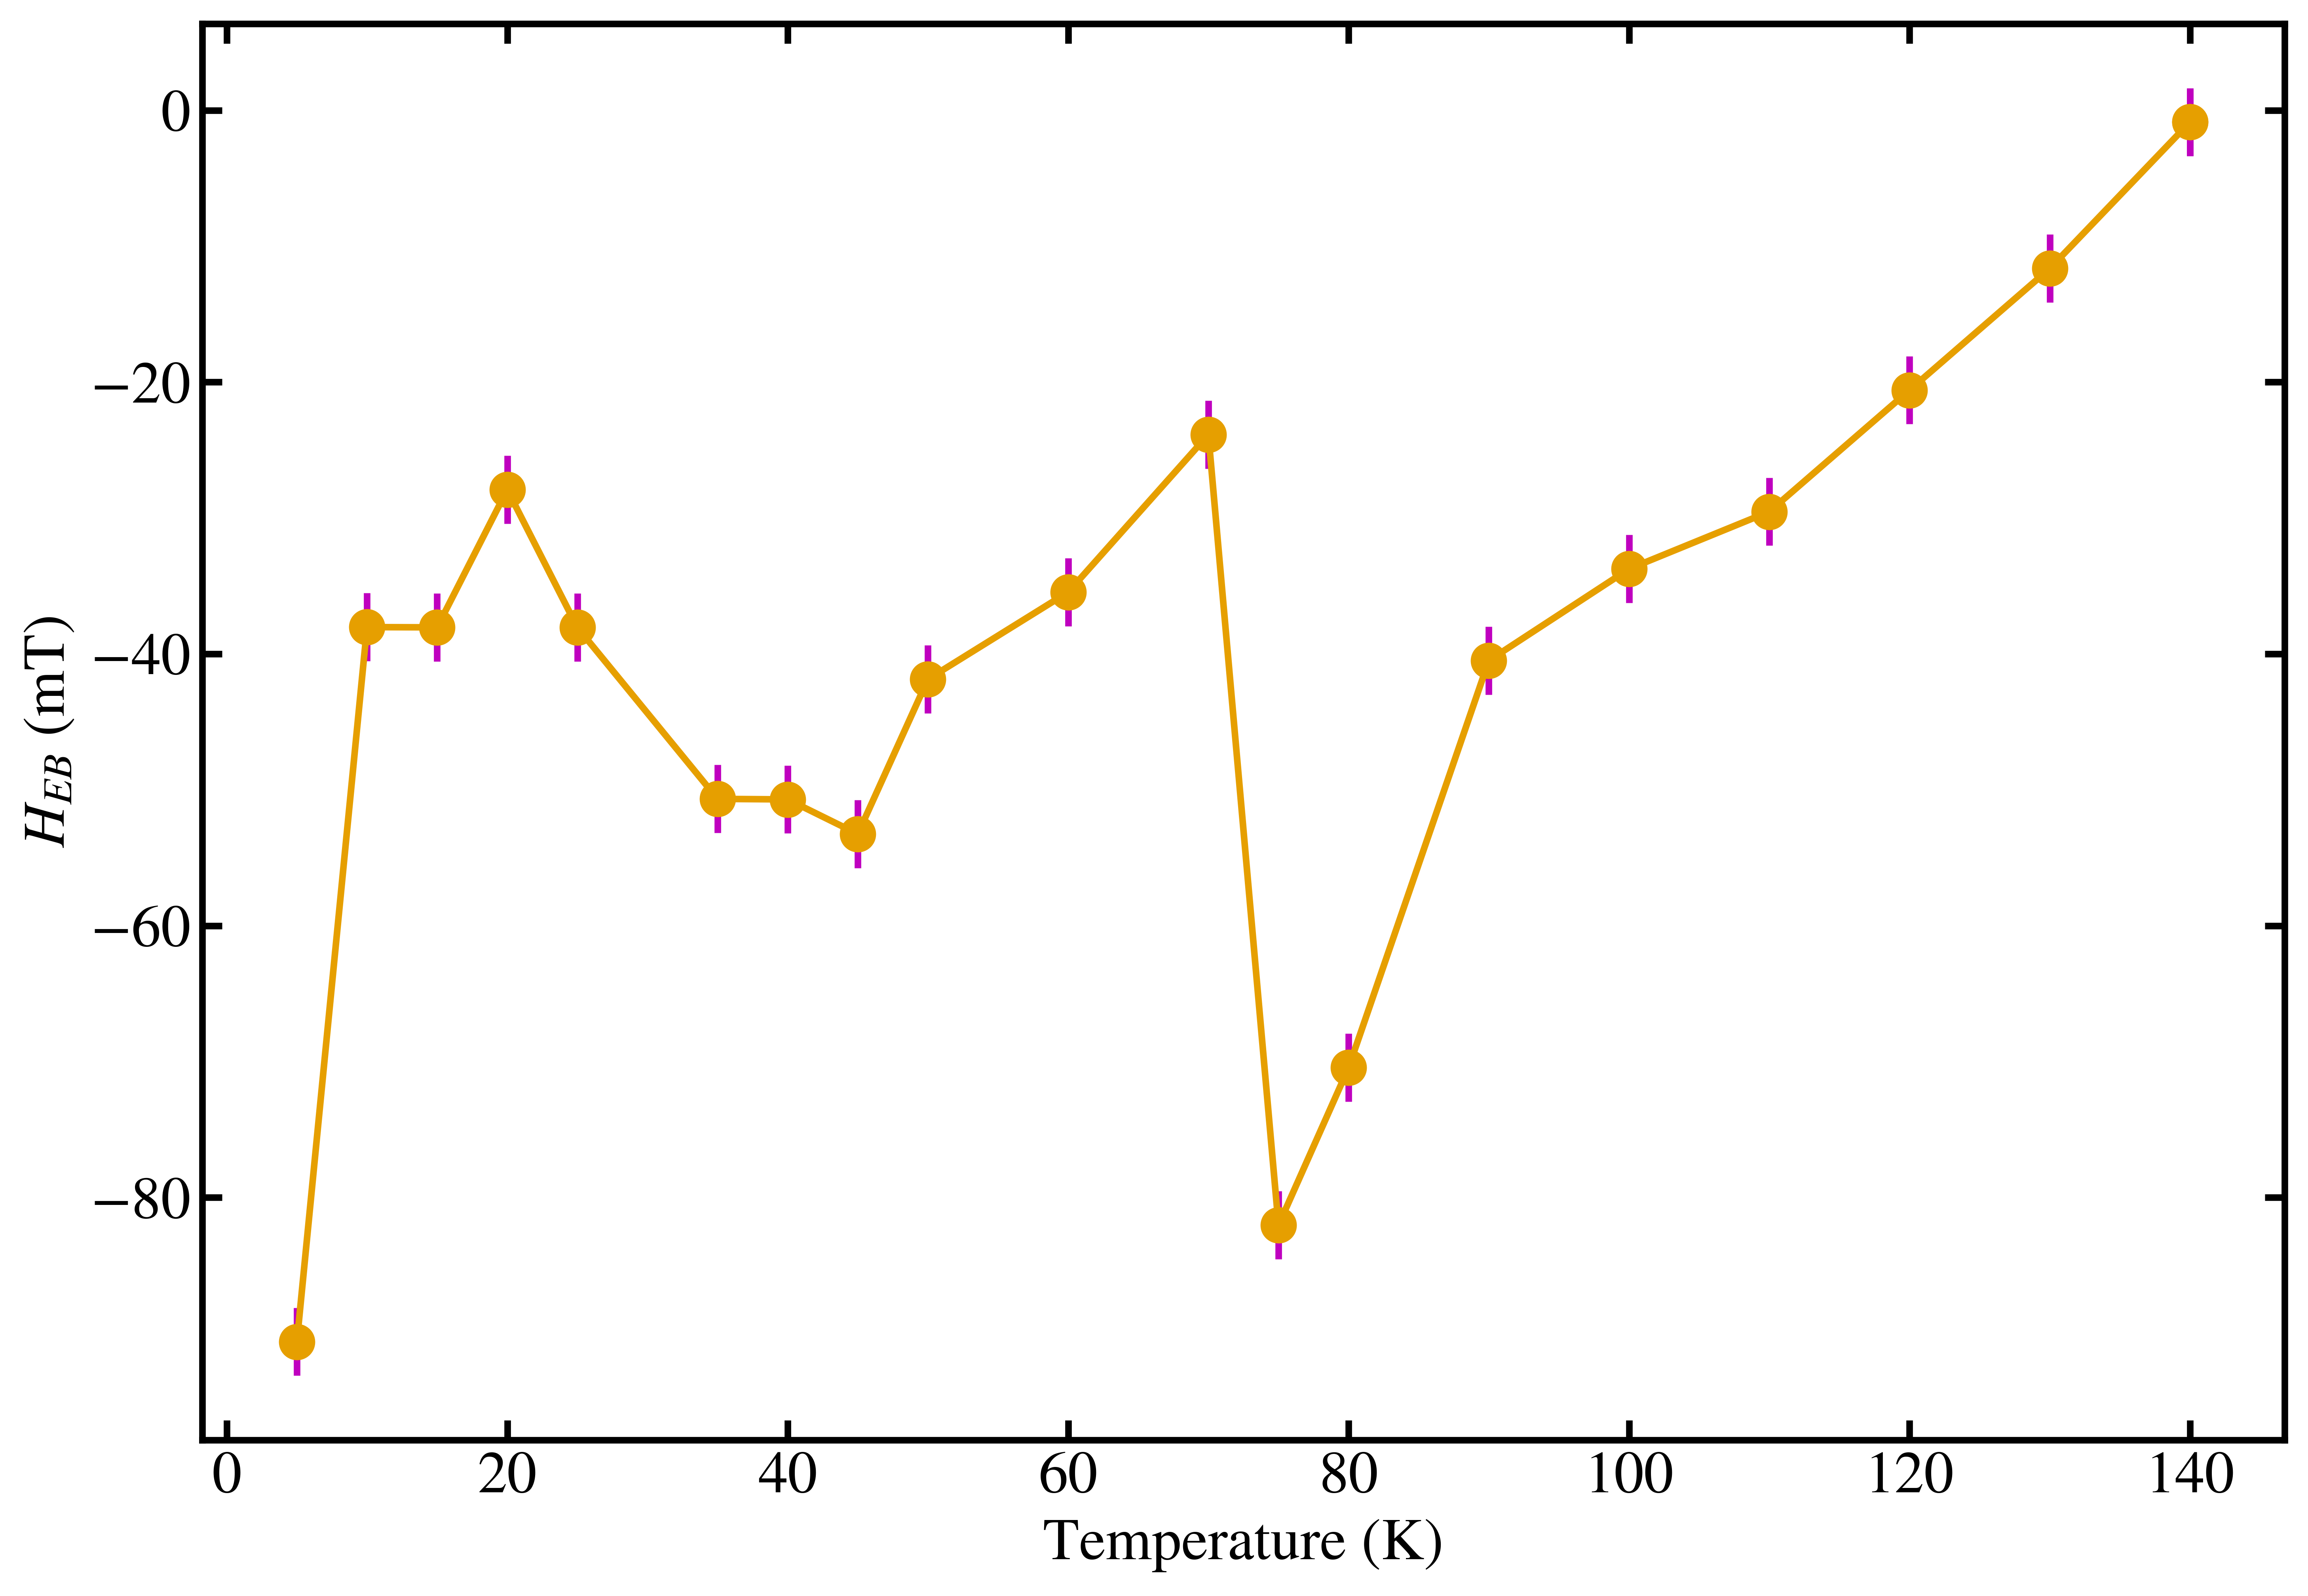

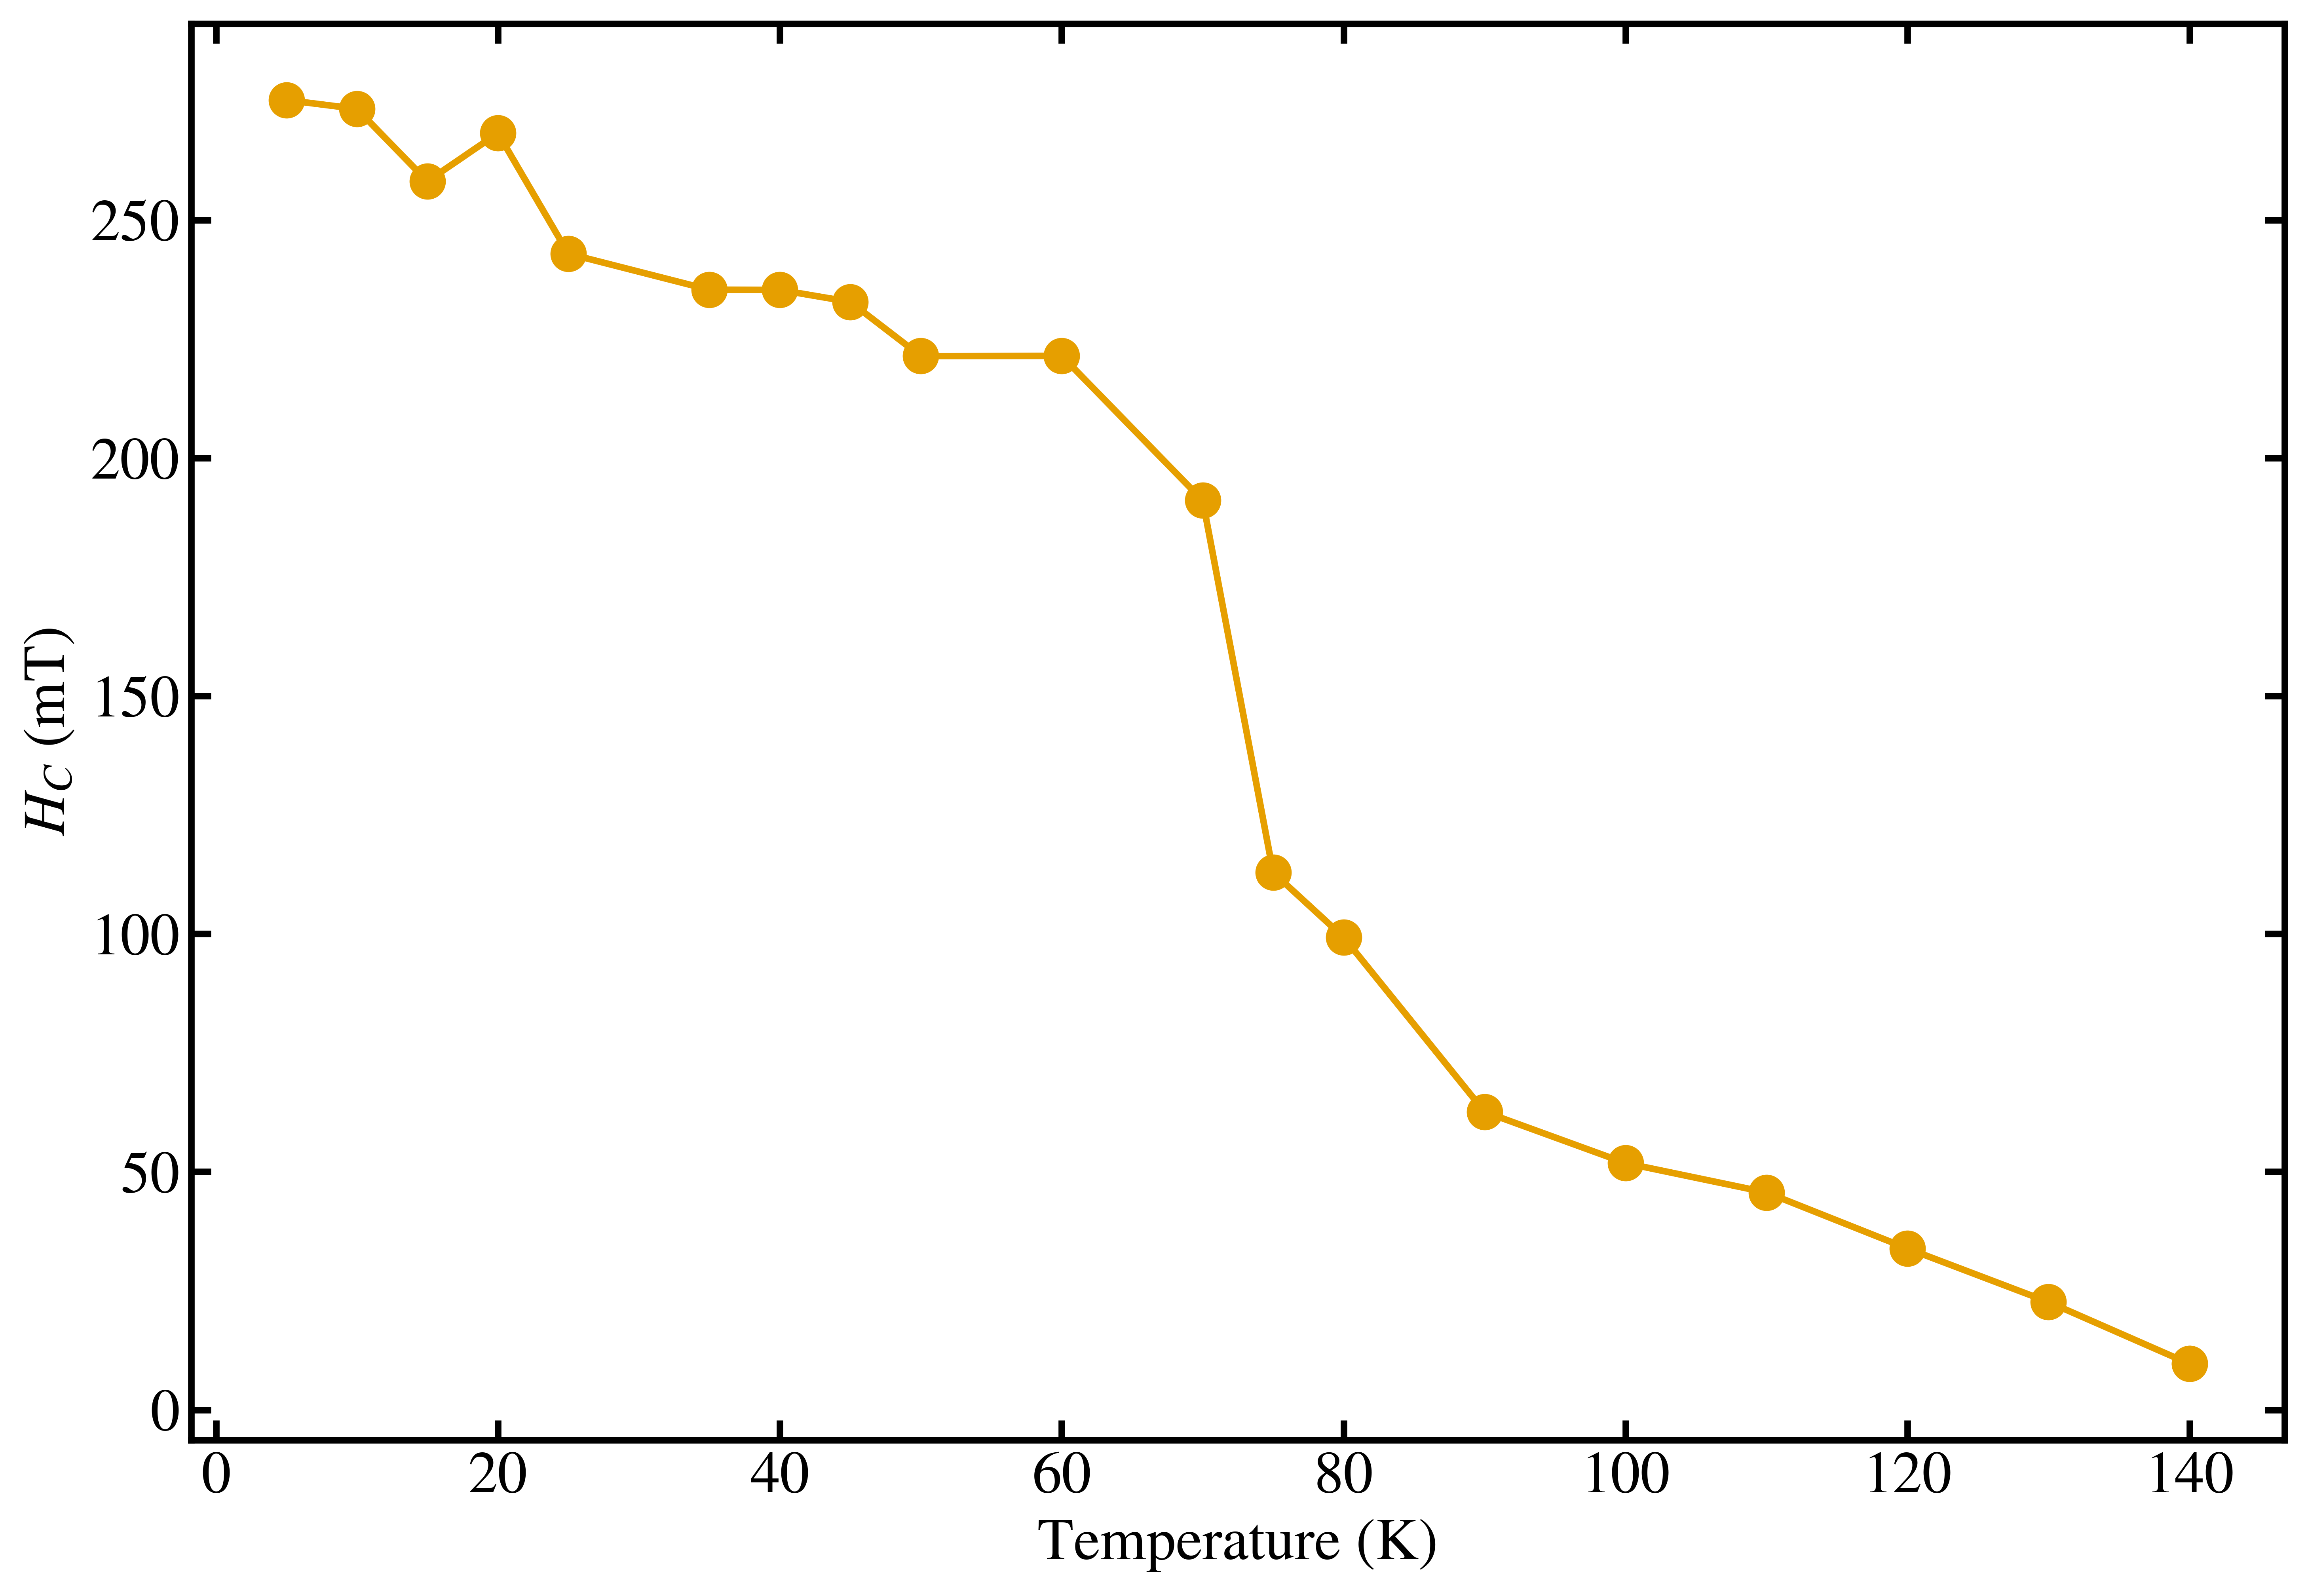

In [5]:
# PF +1T subset: positive pre-field (HEB < 0) from complete dataset
idx_p1t = negEB
res_p1t = dict(
    T_g        = res_pf['T_g'][idx_p1t],
    H1_g       = res_pf['H1_g'][idx_p1t],
    H2_g       = res_pf['H2_g'][idx_p1t],
    W          = res_pf['W'][idx_p1t],
    HEB        = res_pf['HEB'][idx_p1t],
    sorted_T   = np.sort(res_pf['T_g'][idx_p1t]),
    sorted_HEB = sort_serial(list(res_pf['T_g'][idx_p1t]), list(res_pf['HEB'][idx_p1t])),
    sorted_W   = sort_serial(list(res_pf['T_g'][idx_p1t]), list(res_pf['W'][idx_p1t])),
    Field_g    = [res_pf['Field_g'][i] for i in idx_p1t],
    Vxy_norm_g = [res_pf['Vxy_norm_g'][i] for i in idx_p1t],
    Vxy_err_g  = [res_pf['Vxy_err_g'][i] for i in idx_p1t],
)
heb_hc_summary(res_p1t)

[WARNING] T=30 K not found


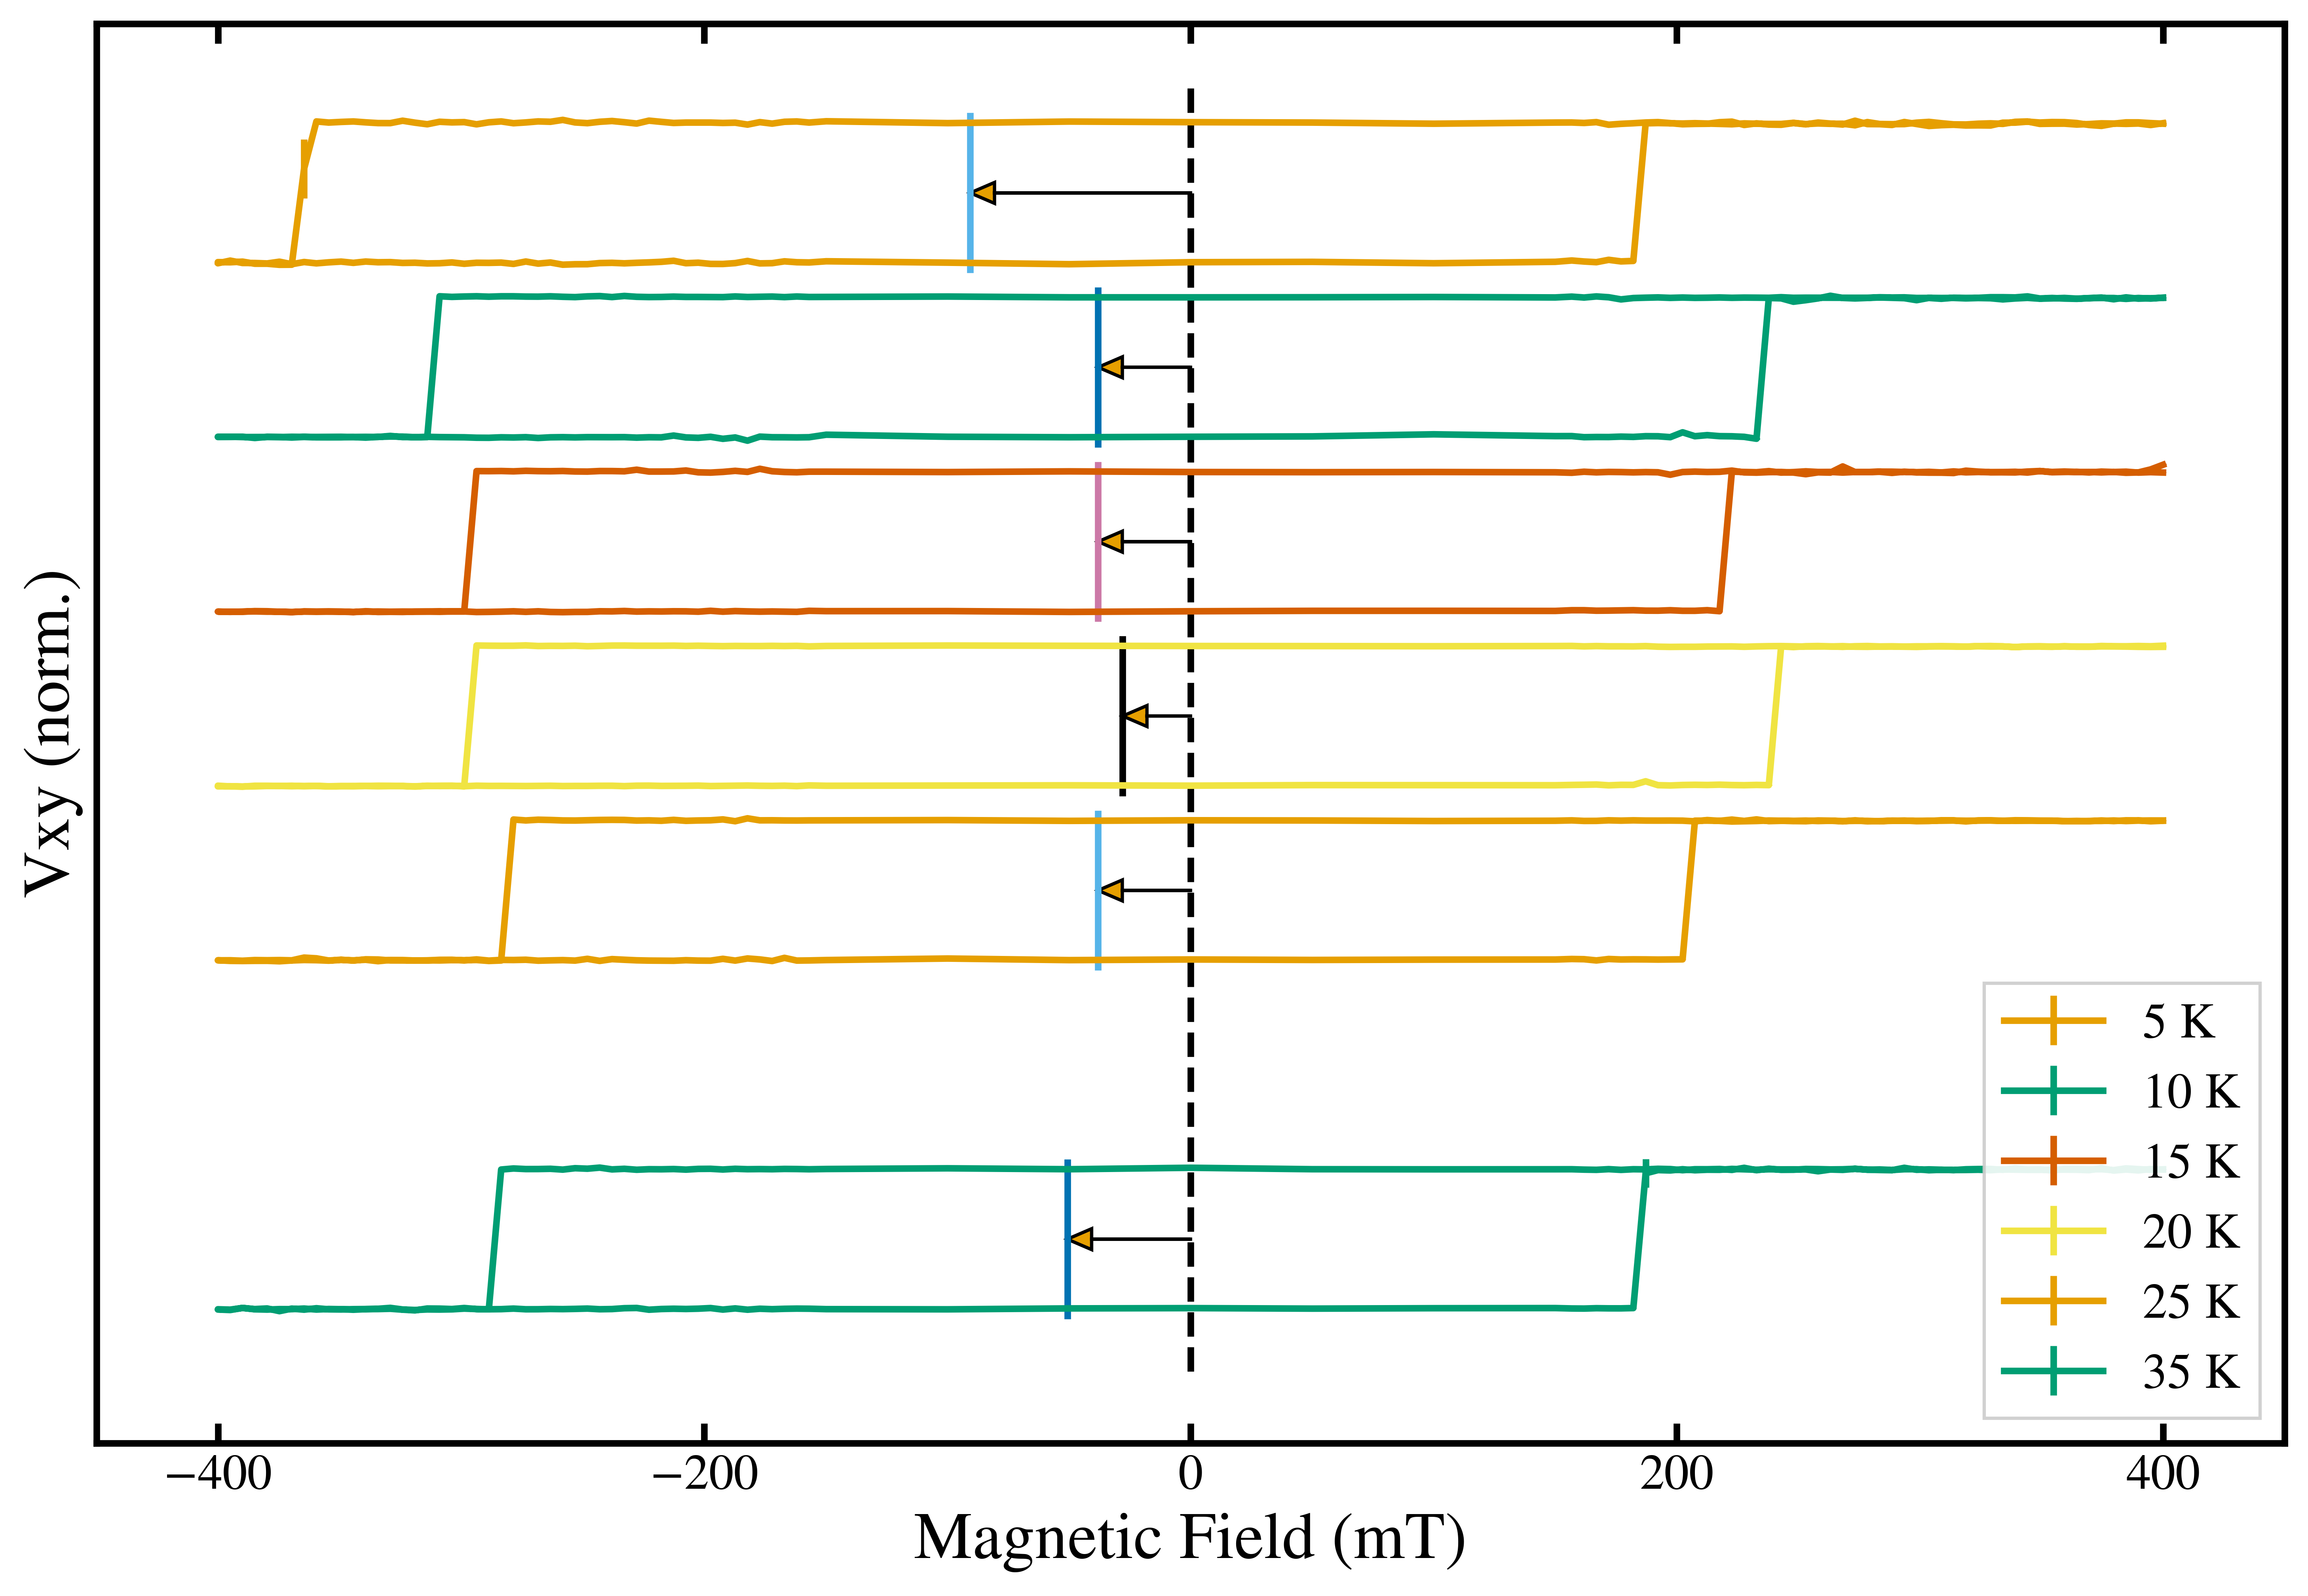

[WARNING] T=65 K not found


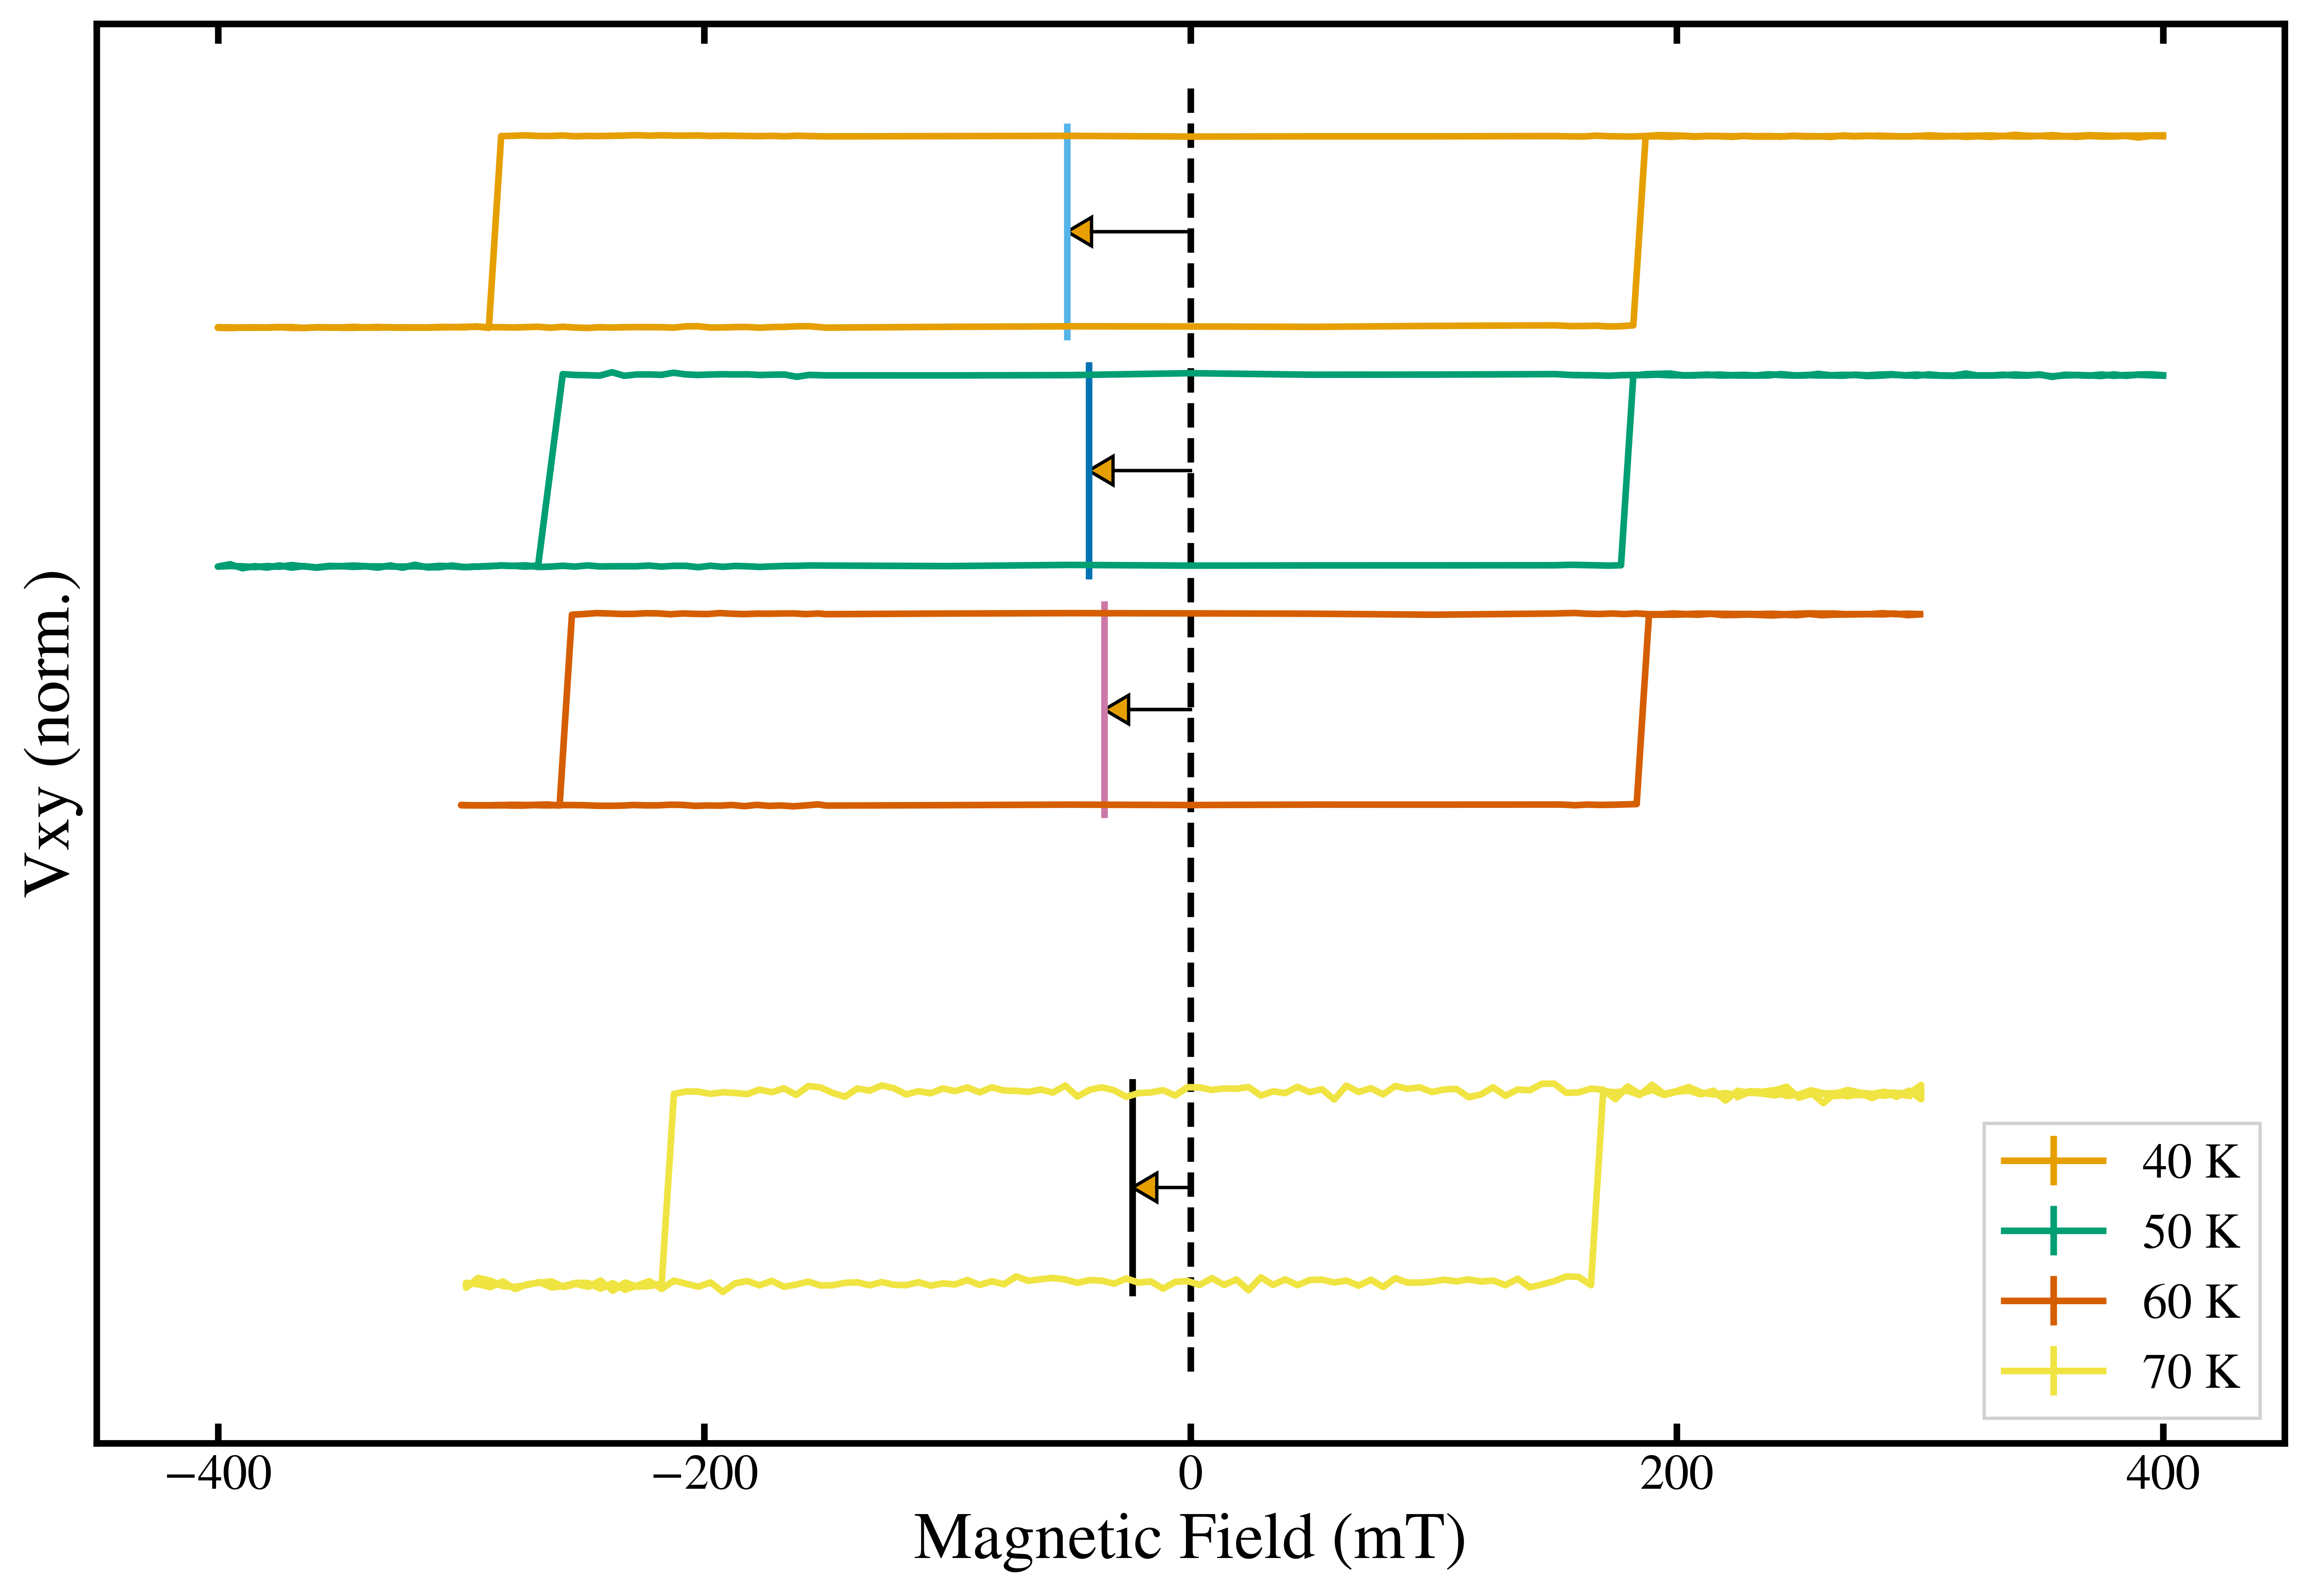

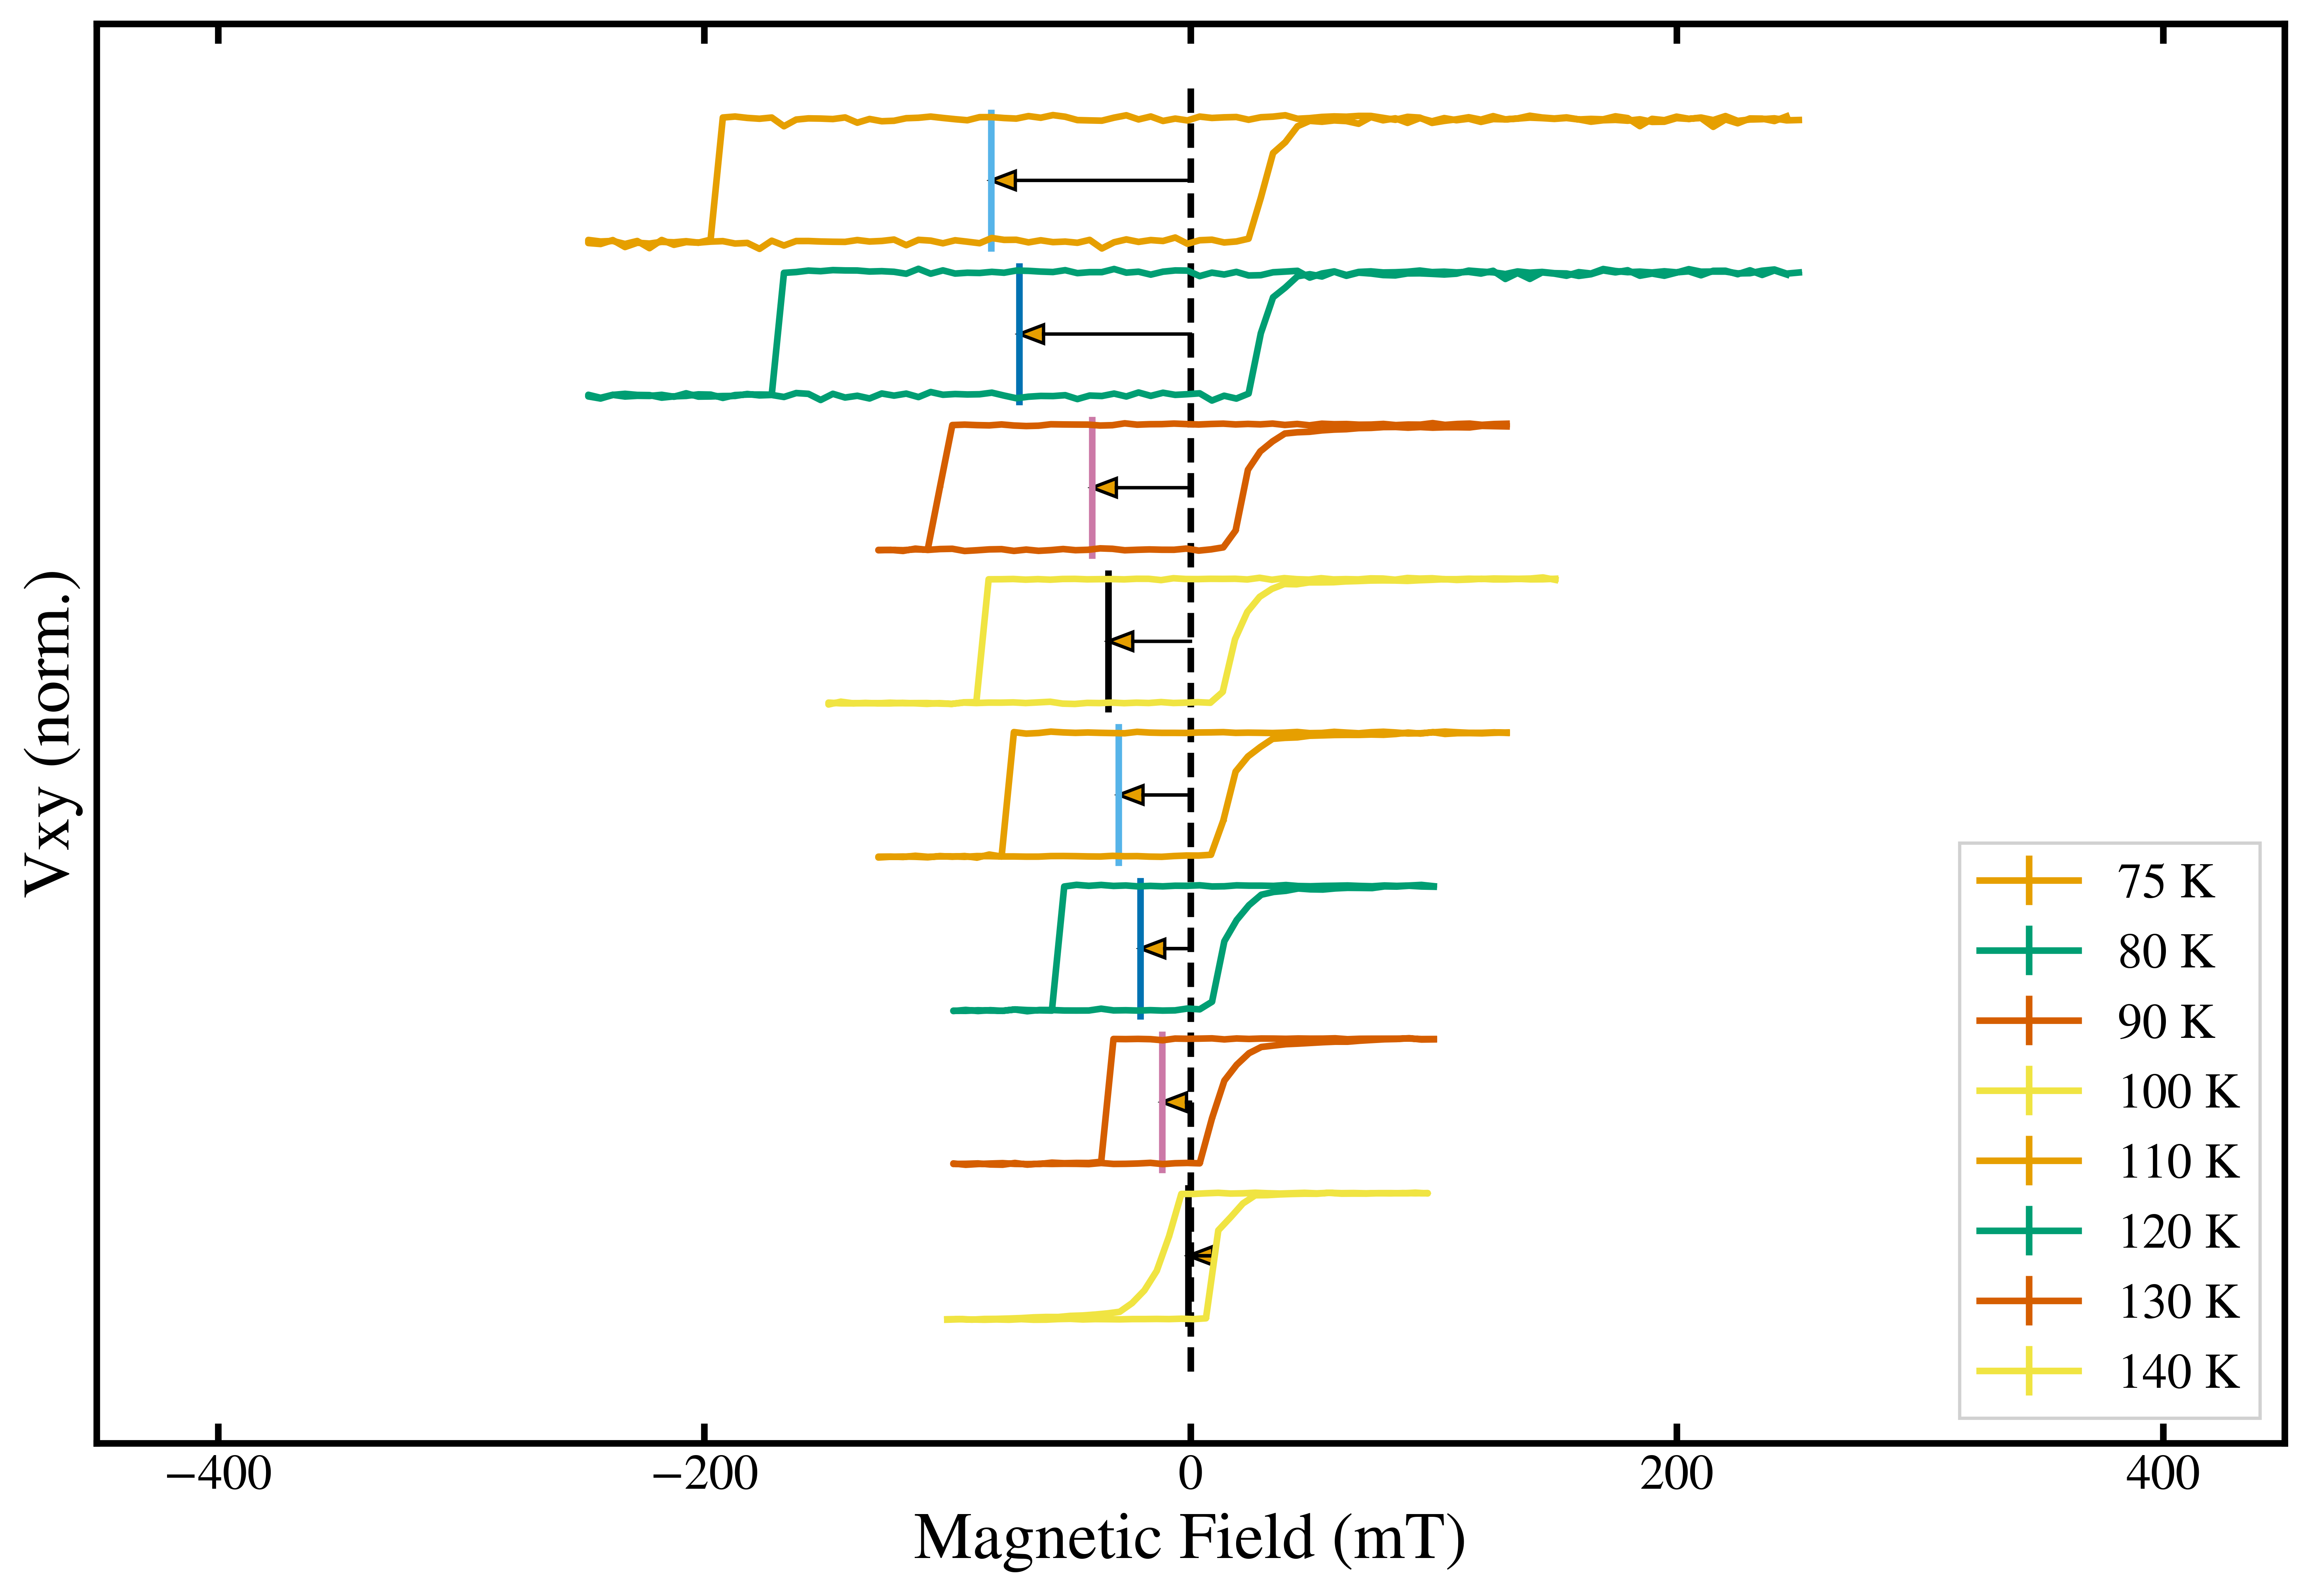

In [6]:
# Waterfall 5–35 K
waterfall_stack(res_p1t, [
    (5, 20.5, False), (10, 18, False), (15, 15.5, False),
    (20, 13, False), (25, 10.5, False), (30, 8, False), (35, 5.5, False),
], dashed_xlim=(22, 3.5))

# Waterfall 40–70 K
waterfall_stack(res_p1t, [
    (40, 20.5, False), (50, 18, False), (60, 15.5, False),
    (65, 13, False), (70, 10.5, False),
], dashed_xlim=(22, 8.5))

# Waterfall 75–140 K
waterfall_stack(res_p1t, [
    (75, 20.5, False), (80, 18, False), (90, 15.5, False), (100, 13, False),
    (110, 10.5, False), (120, 8, False), (130, 5.5, False), (140, 3, False),
], dashed_xlim=(22, 1))

---
## § PF −1T (Negative Pre-field) — HEB & Waterfall

Filtered from `res_pf` using `posEB` indices (HEB > 0 = negative pre-field direction).
**Waterfalls:** 5–35 K, 40–70 K, 75–140 K.

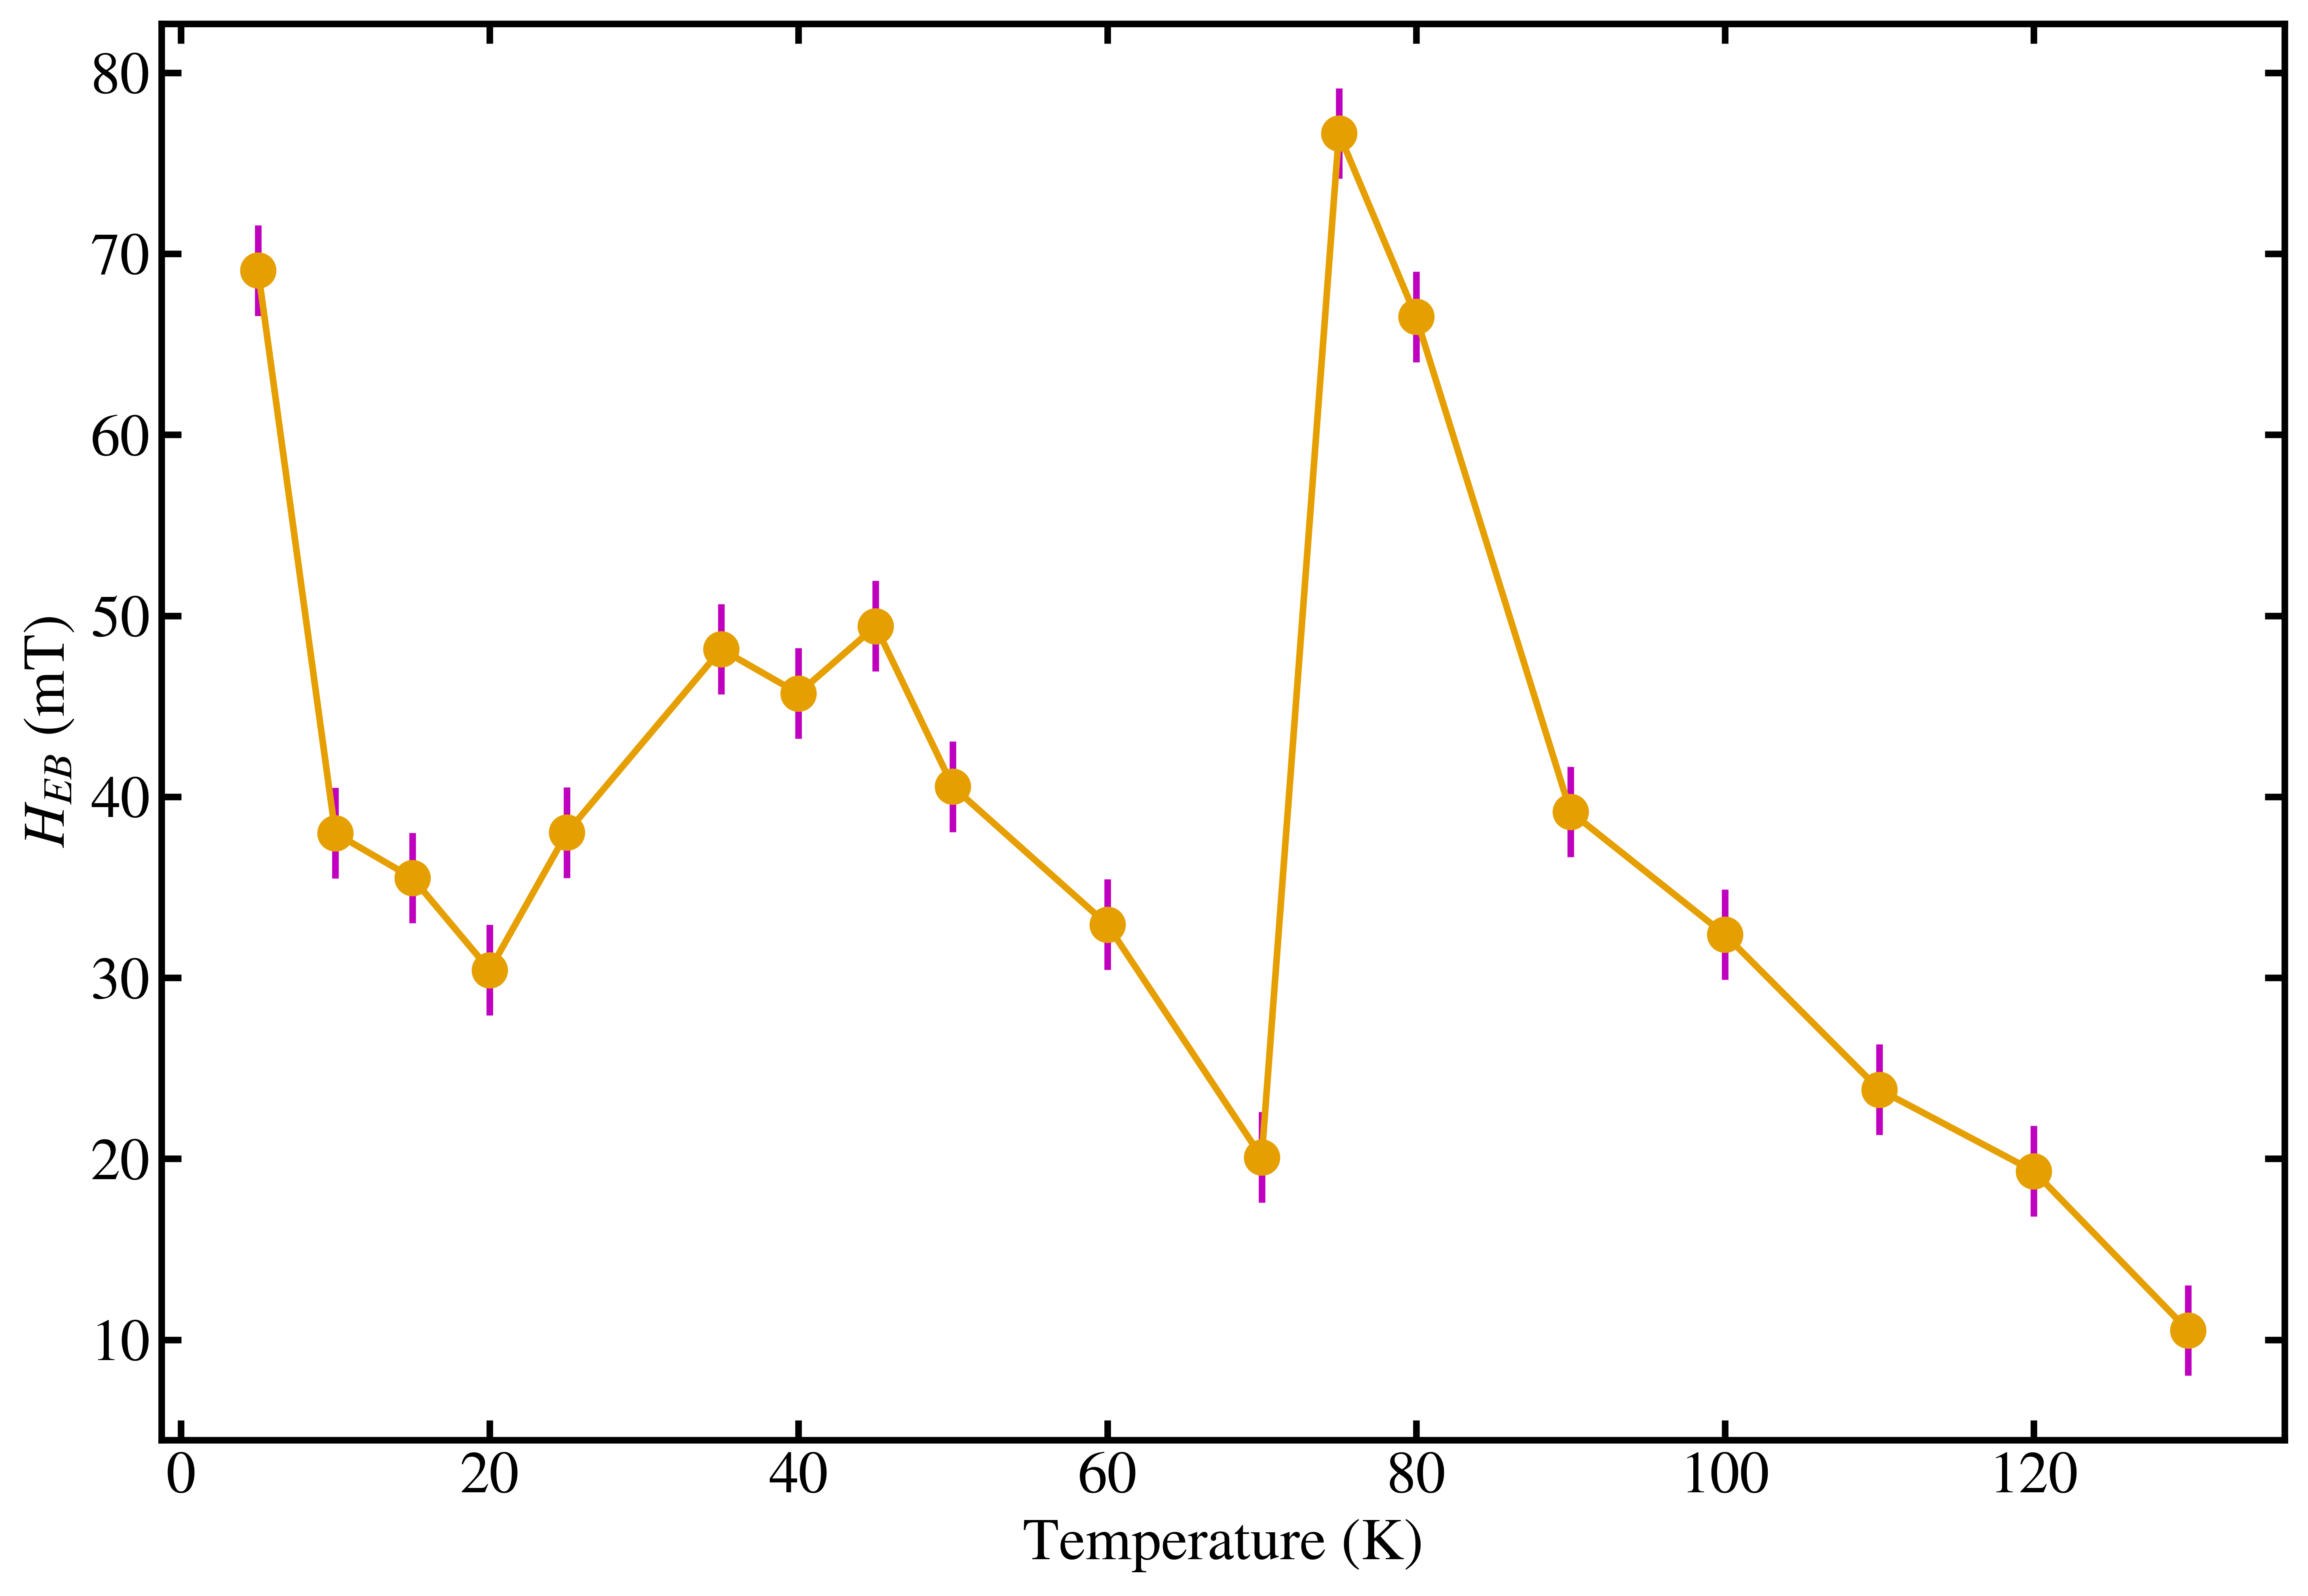

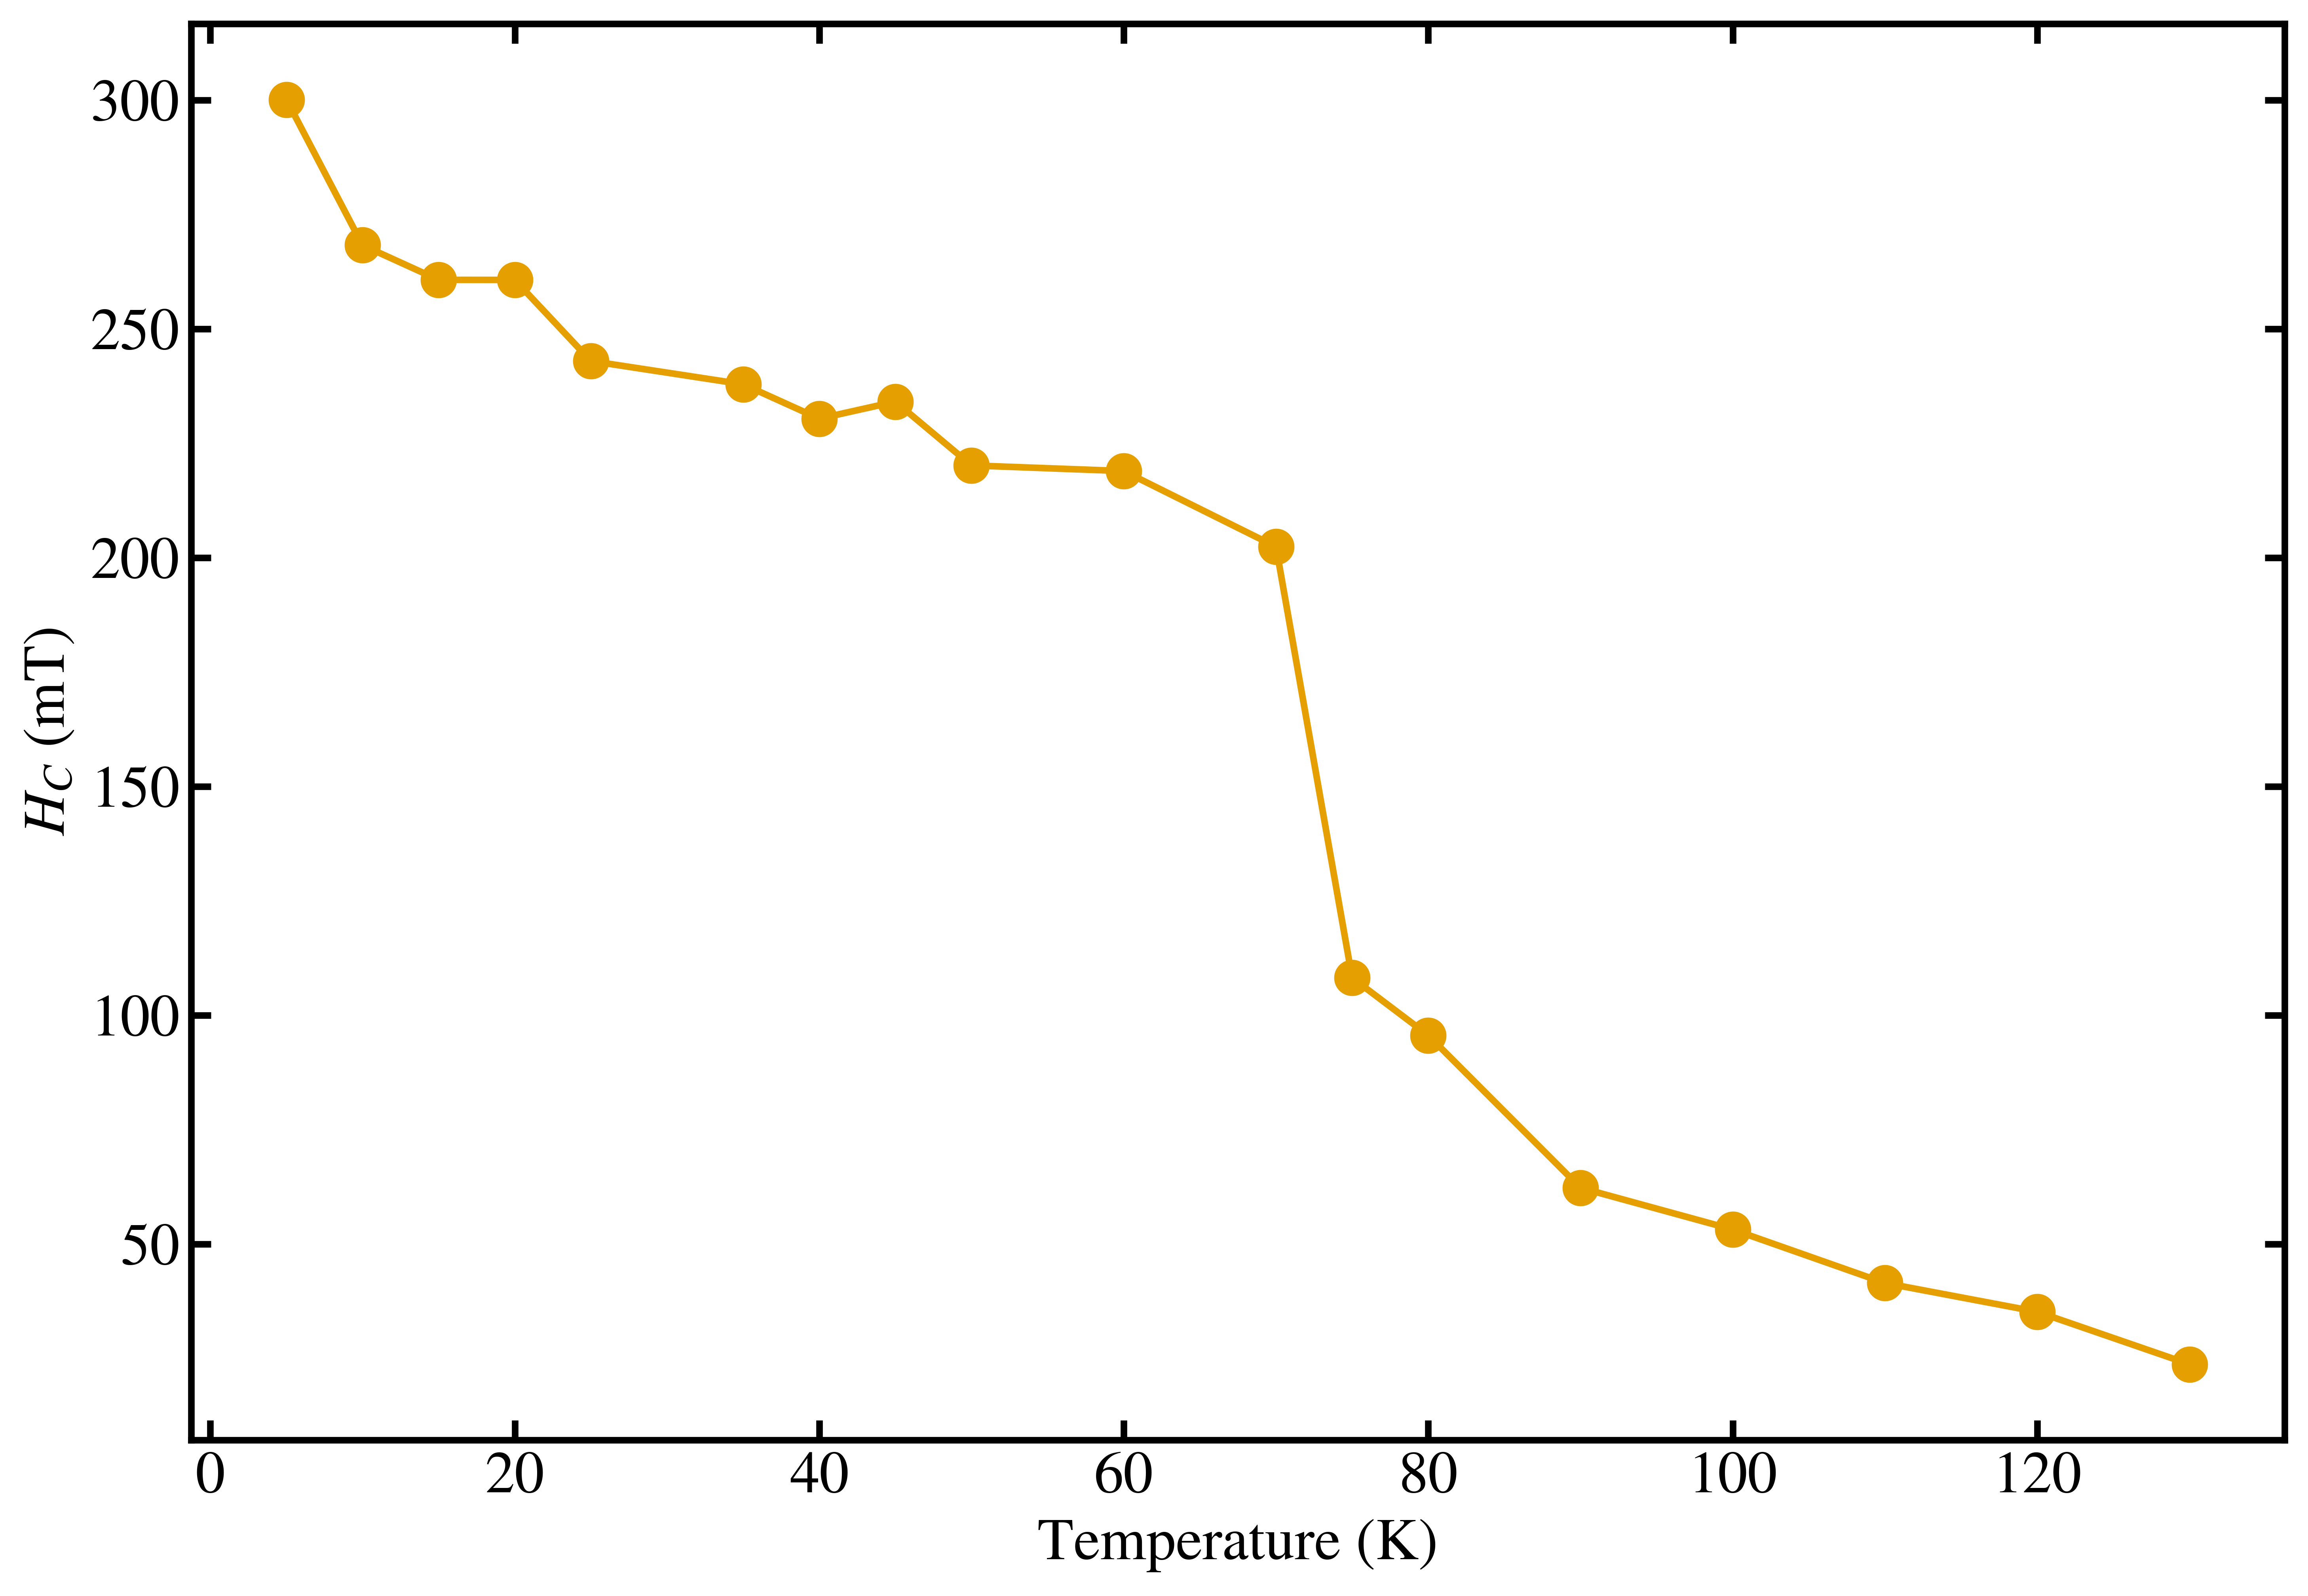

In [7]:
# PF −1T subset: negative pre-field (HEB > 0) from complete dataset
idx_m1t = posEB
res_m1t = dict(
    T_g        = res_pf['T_g'][idx_m1t],
    H1_g       = res_pf['H1_g'][idx_m1t],
    H2_g       = res_pf['H2_g'][idx_m1t],
    W          = res_pf['W'][idx_m1t],
    HEB        = res_pf['HEB'][idx_m1t],
    sorted_T   = np.sort(res_pf['T_g'][idx_m1t]),
    sorted_HEB = sort_serial(list(res_pf['T_g'][idx_m1t]), list(res_pf['HEB'][idx_m1t])),
    sorted_W   = sort_serial(list(res_pf['T_g'][idx_m1t]), list(res_pf['W'][idx_m1t])),
    Field_g    = [res_pf['Field_g'][i] for i in idx_m1t],
    Vxy_norm_g = [res_pf['Vxy_norm_g'][i] for i in idx_m1t],
    Vxy_err_g  = [res_pf['Vxy_err_g'][i] for i in idx_m1t],
)
heb_hc_summary(res_m1t)

[WARNING] T=30 K not found


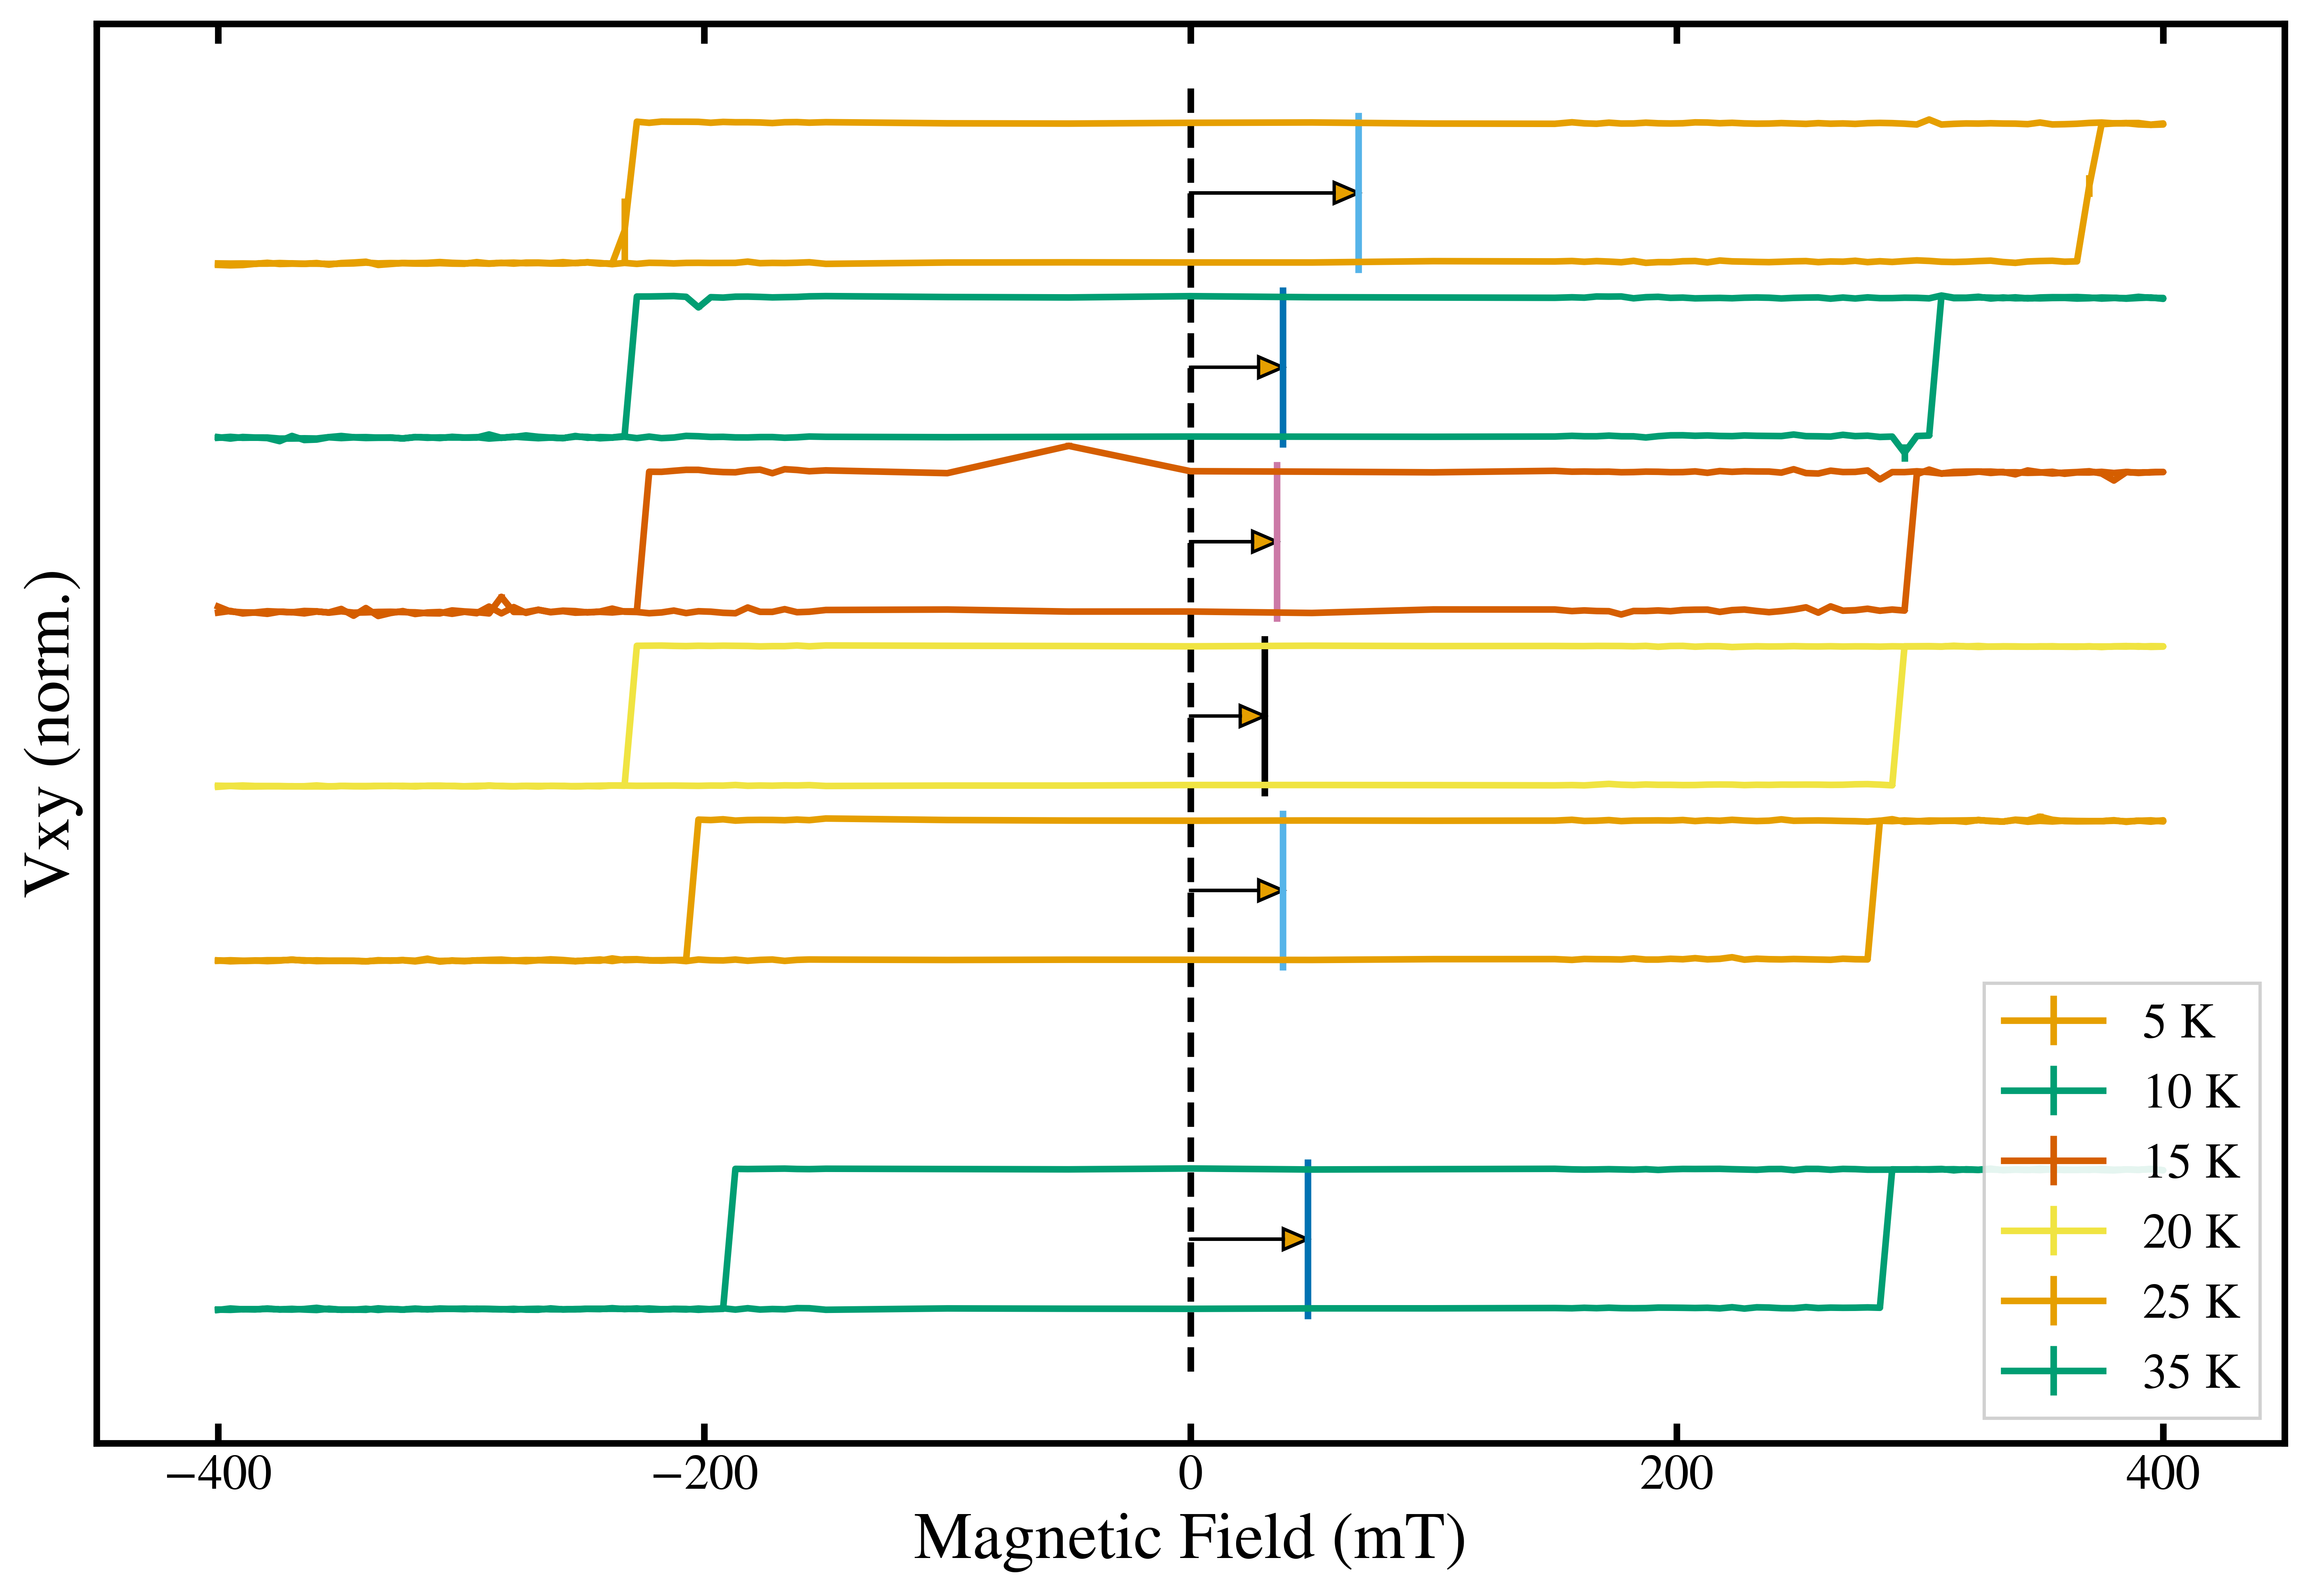

[WARNING] T=65 K not found


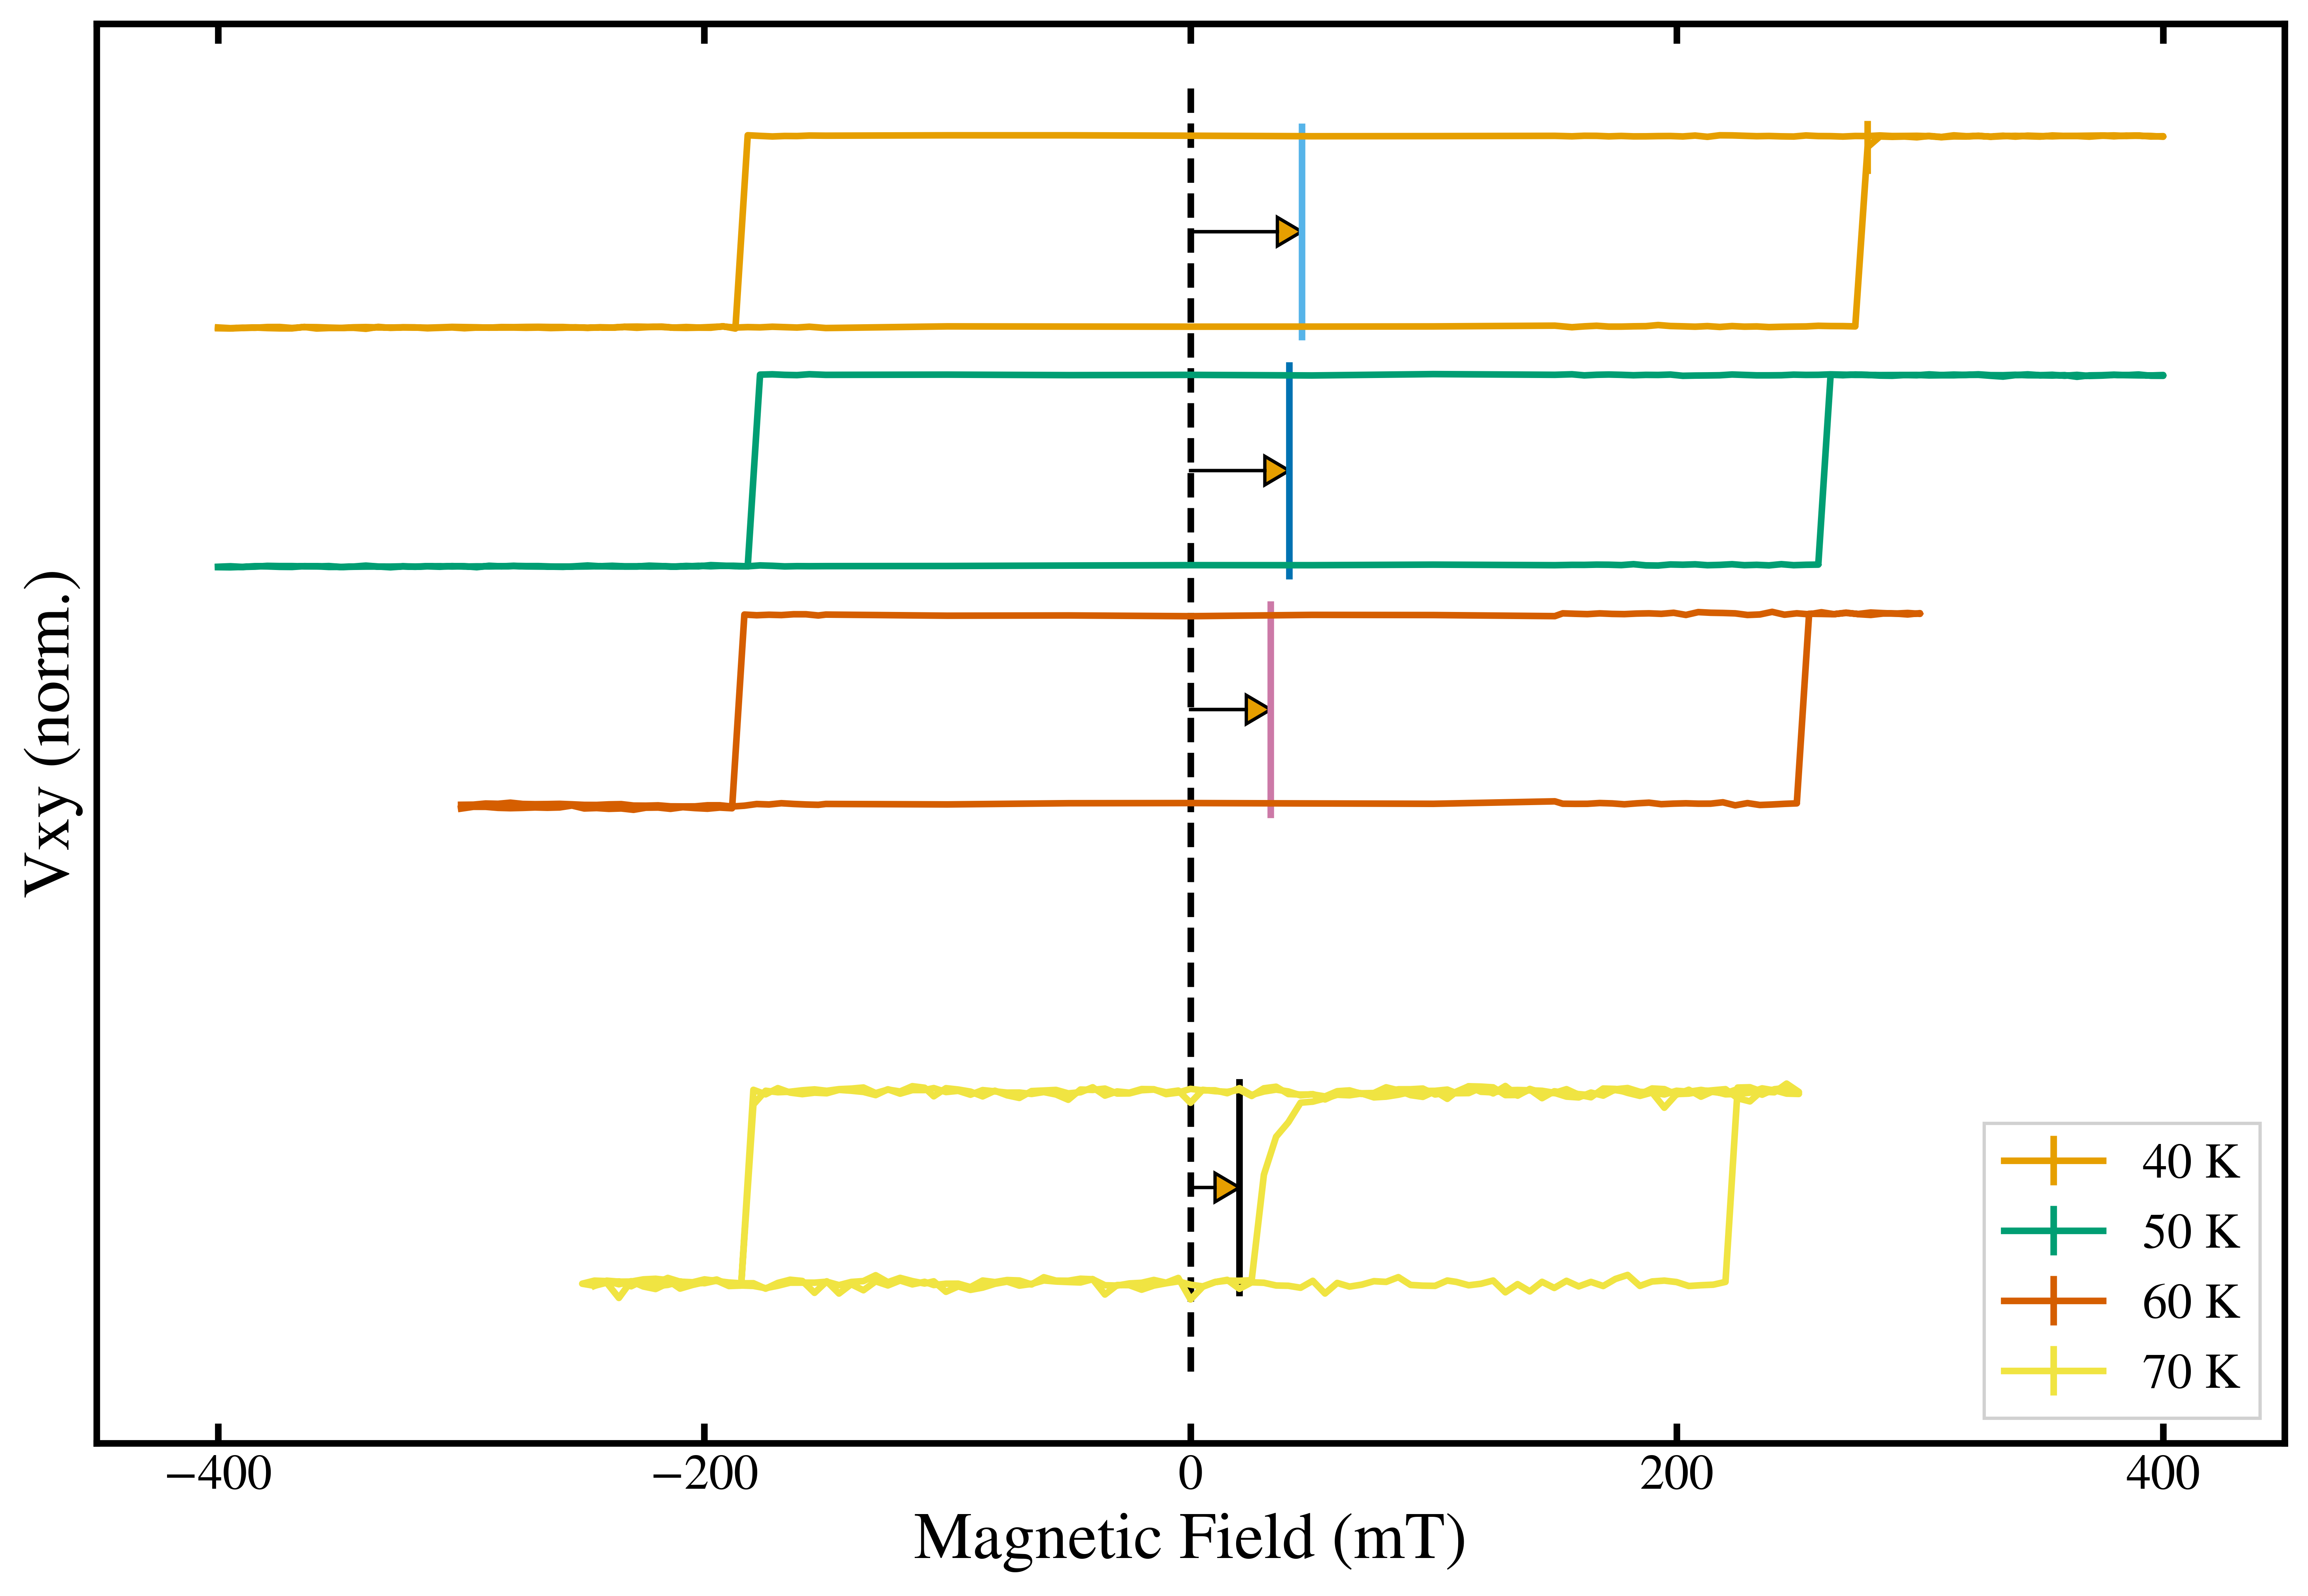

[WARNING] T=140 K not found


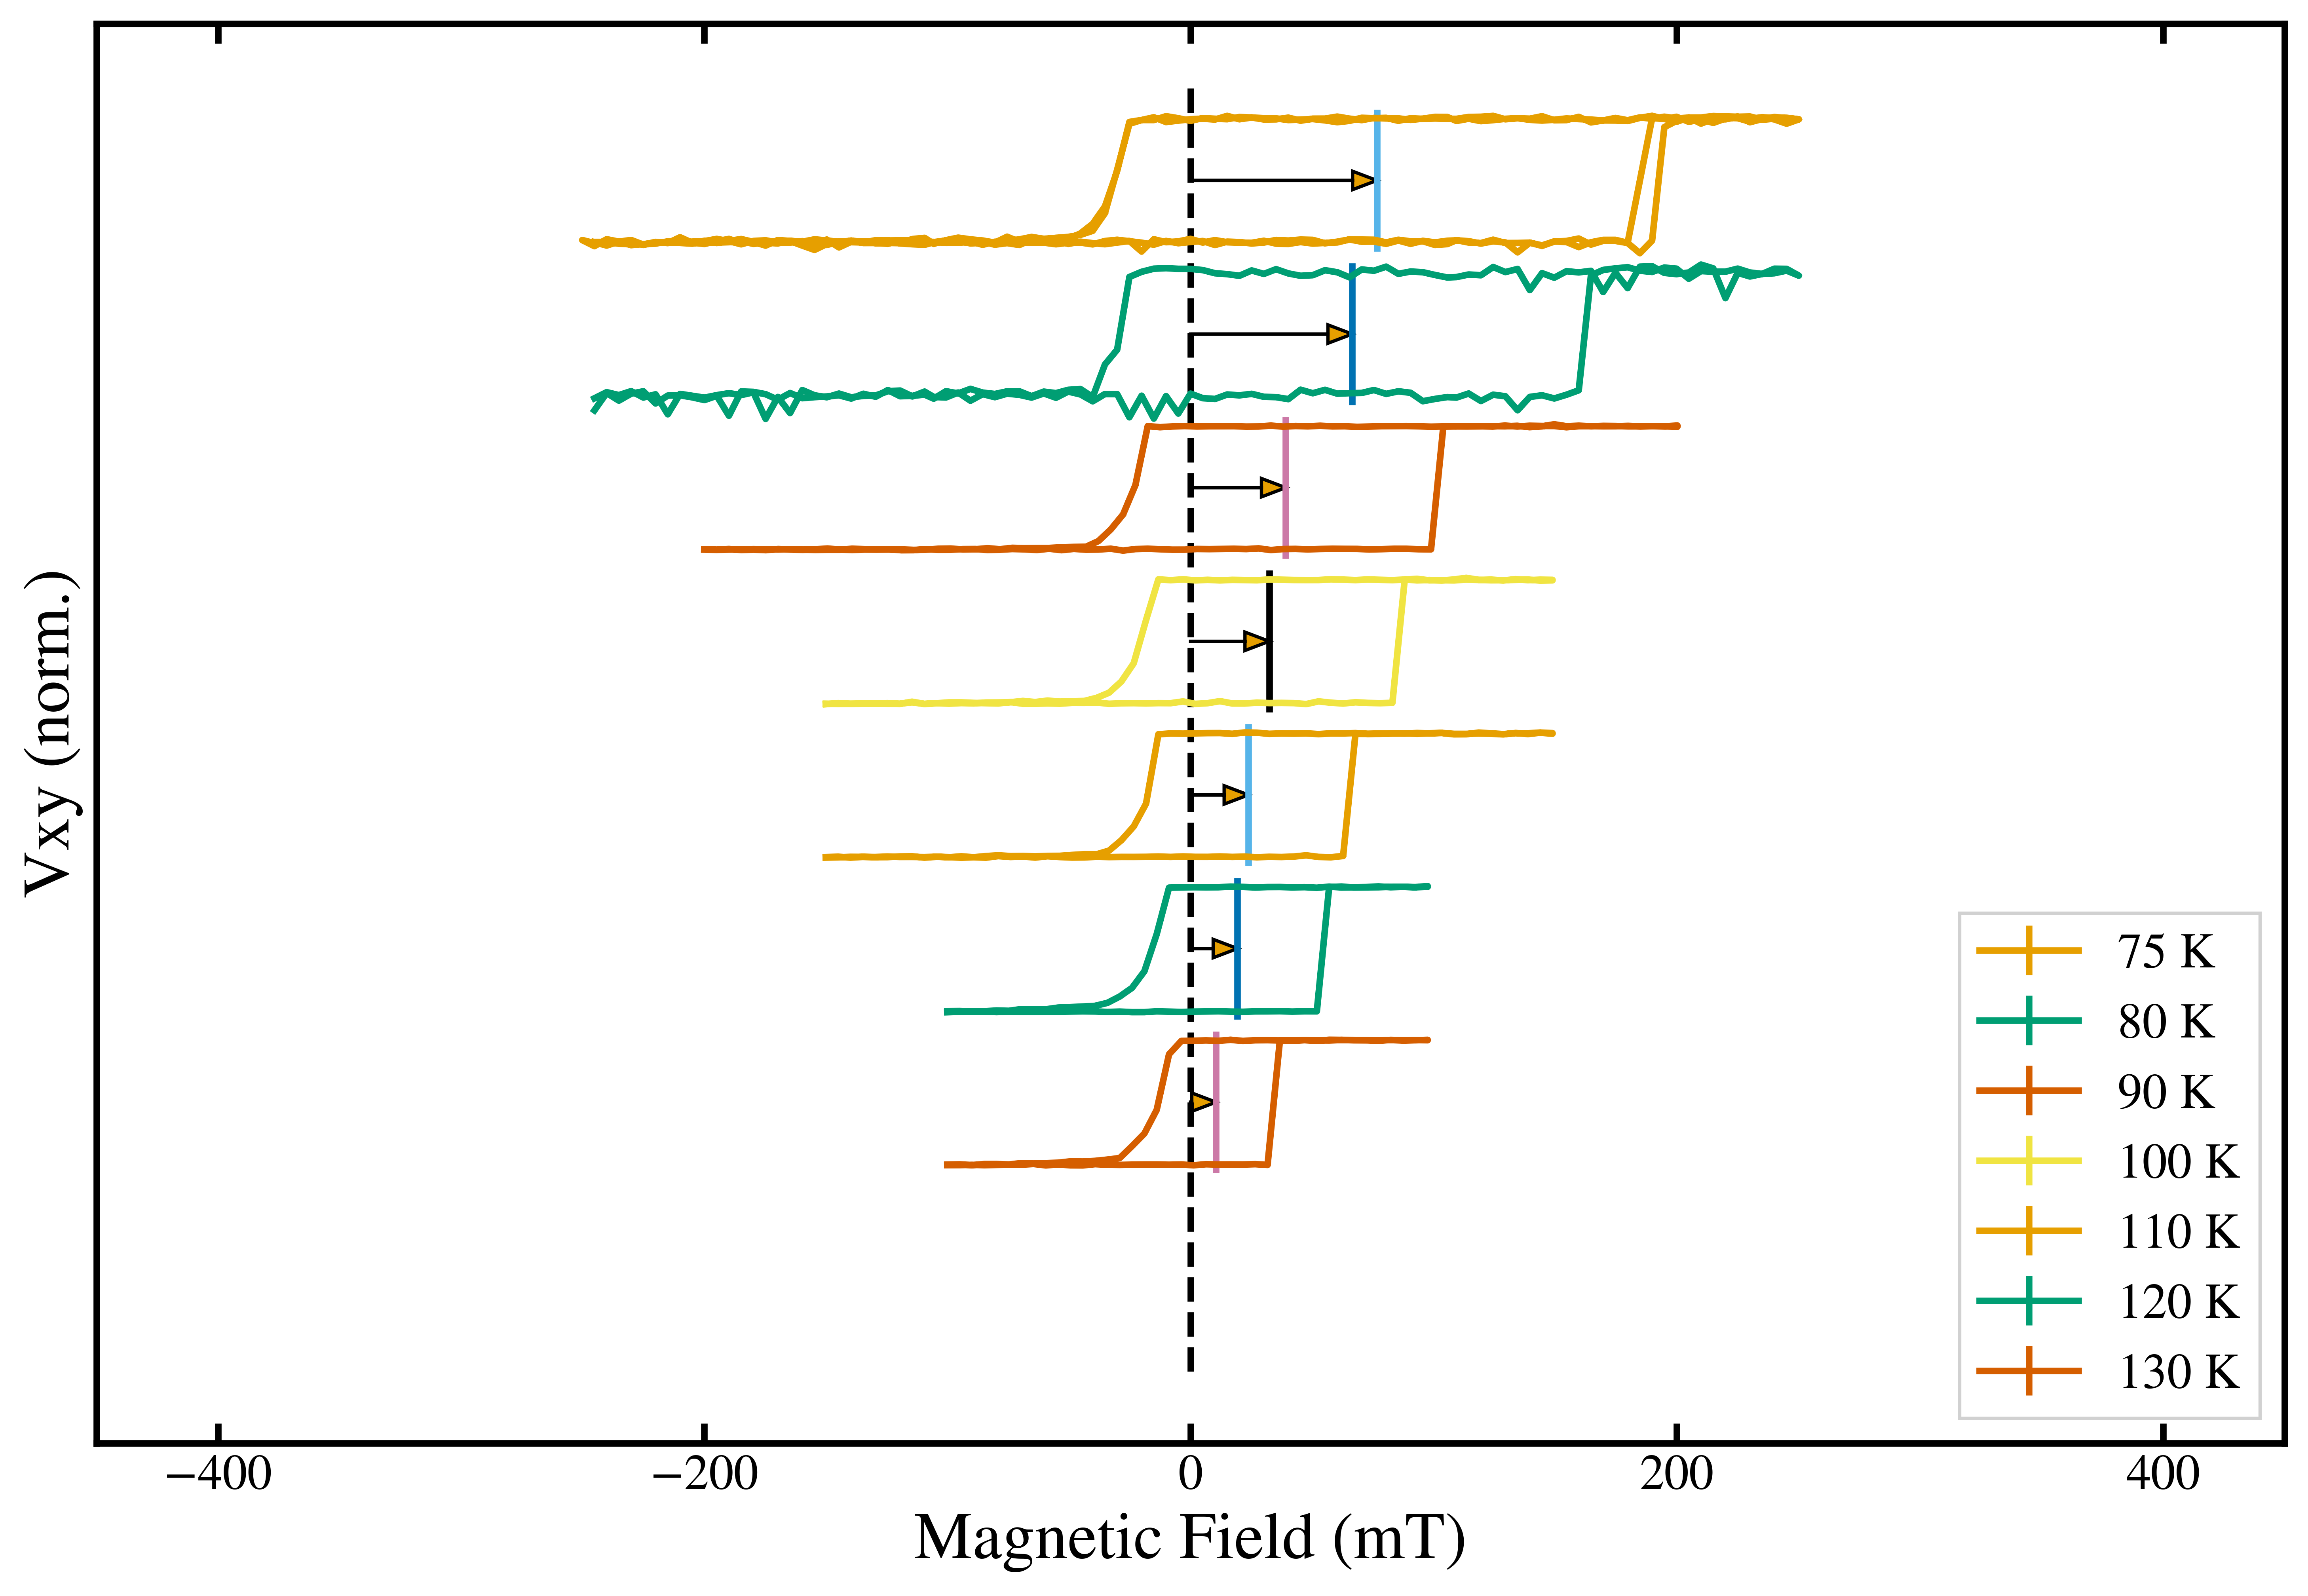

In [8]:
# Waterfall 5–35 K
waterfall_stack(res_m1t, [
    (5, 20.5, False), (10, 18, False), (15, 15.5, False),
    (20, 13, False), (25, 10.5, False), (30, 8, False), (35, 5.5, False),
], dashed_xlim=(22, 3.5))

# Waterfall 40–70 K
waterfall_stack(res_m1t, [
    (40, 20.5, False), (50, 18, False), (60, 15.5, False),
    (65, 13, False), (70, 10.5, False),
], dashed_xlim=(22, 8.5))

# Waterfall 75–140 K
waterfall_stack(res_m1t, [
    (75, 20.5, False), (80, 18, False), (90, 15.5, False), (100, 13, False),
    (110, 10.5, False), (120, 8, False), (130, 5.5, False), (140, 3, False),
], dashed_xlim=(22, 1))

---
## § Combined Summary — HEB vs Temperature

All PF directions and FC 8T comparison series, using `posEB` and `negEB` from `res_pf`.

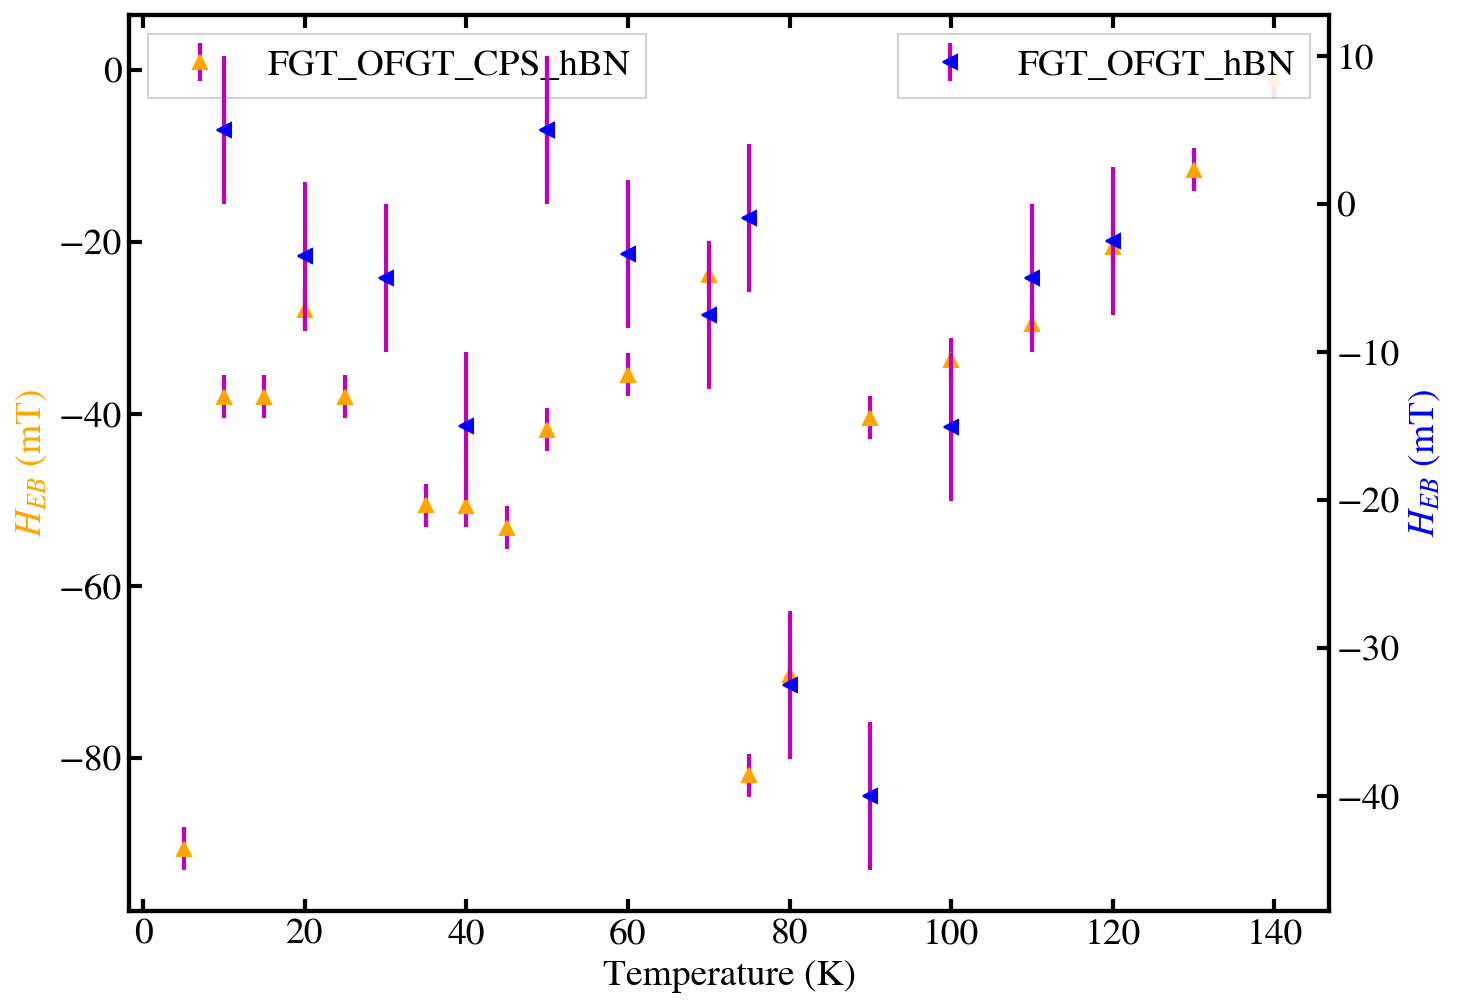

In [9]:
# Dual-axis: FGT_OFGT_CPS_hBN PF vs OFGT comparison
fig, ax1 = plt.subplots()
ax1.errorbar(res_pf['T_g'][negEB], res_pf['HEB'][negEB], 2.5,
             fmt='^', ecolor='m', color='orange')
ax1.set_xlabel('Temperature (K)', fontsize=18)
ax1.set_ylabel('$H_{EB}$ (mT)', fontsize=18, color='orange')
ax2 = ax1.twinx()
ax2.errorbar(T_OFGT, H_OFGT, 5, fmt='<', ecolor='m', color='blue')
ax2.set_ylabel('$H_{EB}$ (mT)', fontsize=18, color='blue')
ax1.legend(['FGT_OFGT_CPS_hBN'], loc='upper left')
ax2.legend(['FGT_OFGT_hBN'], loc='upper right')
plt.tight_layout();  plt.show()

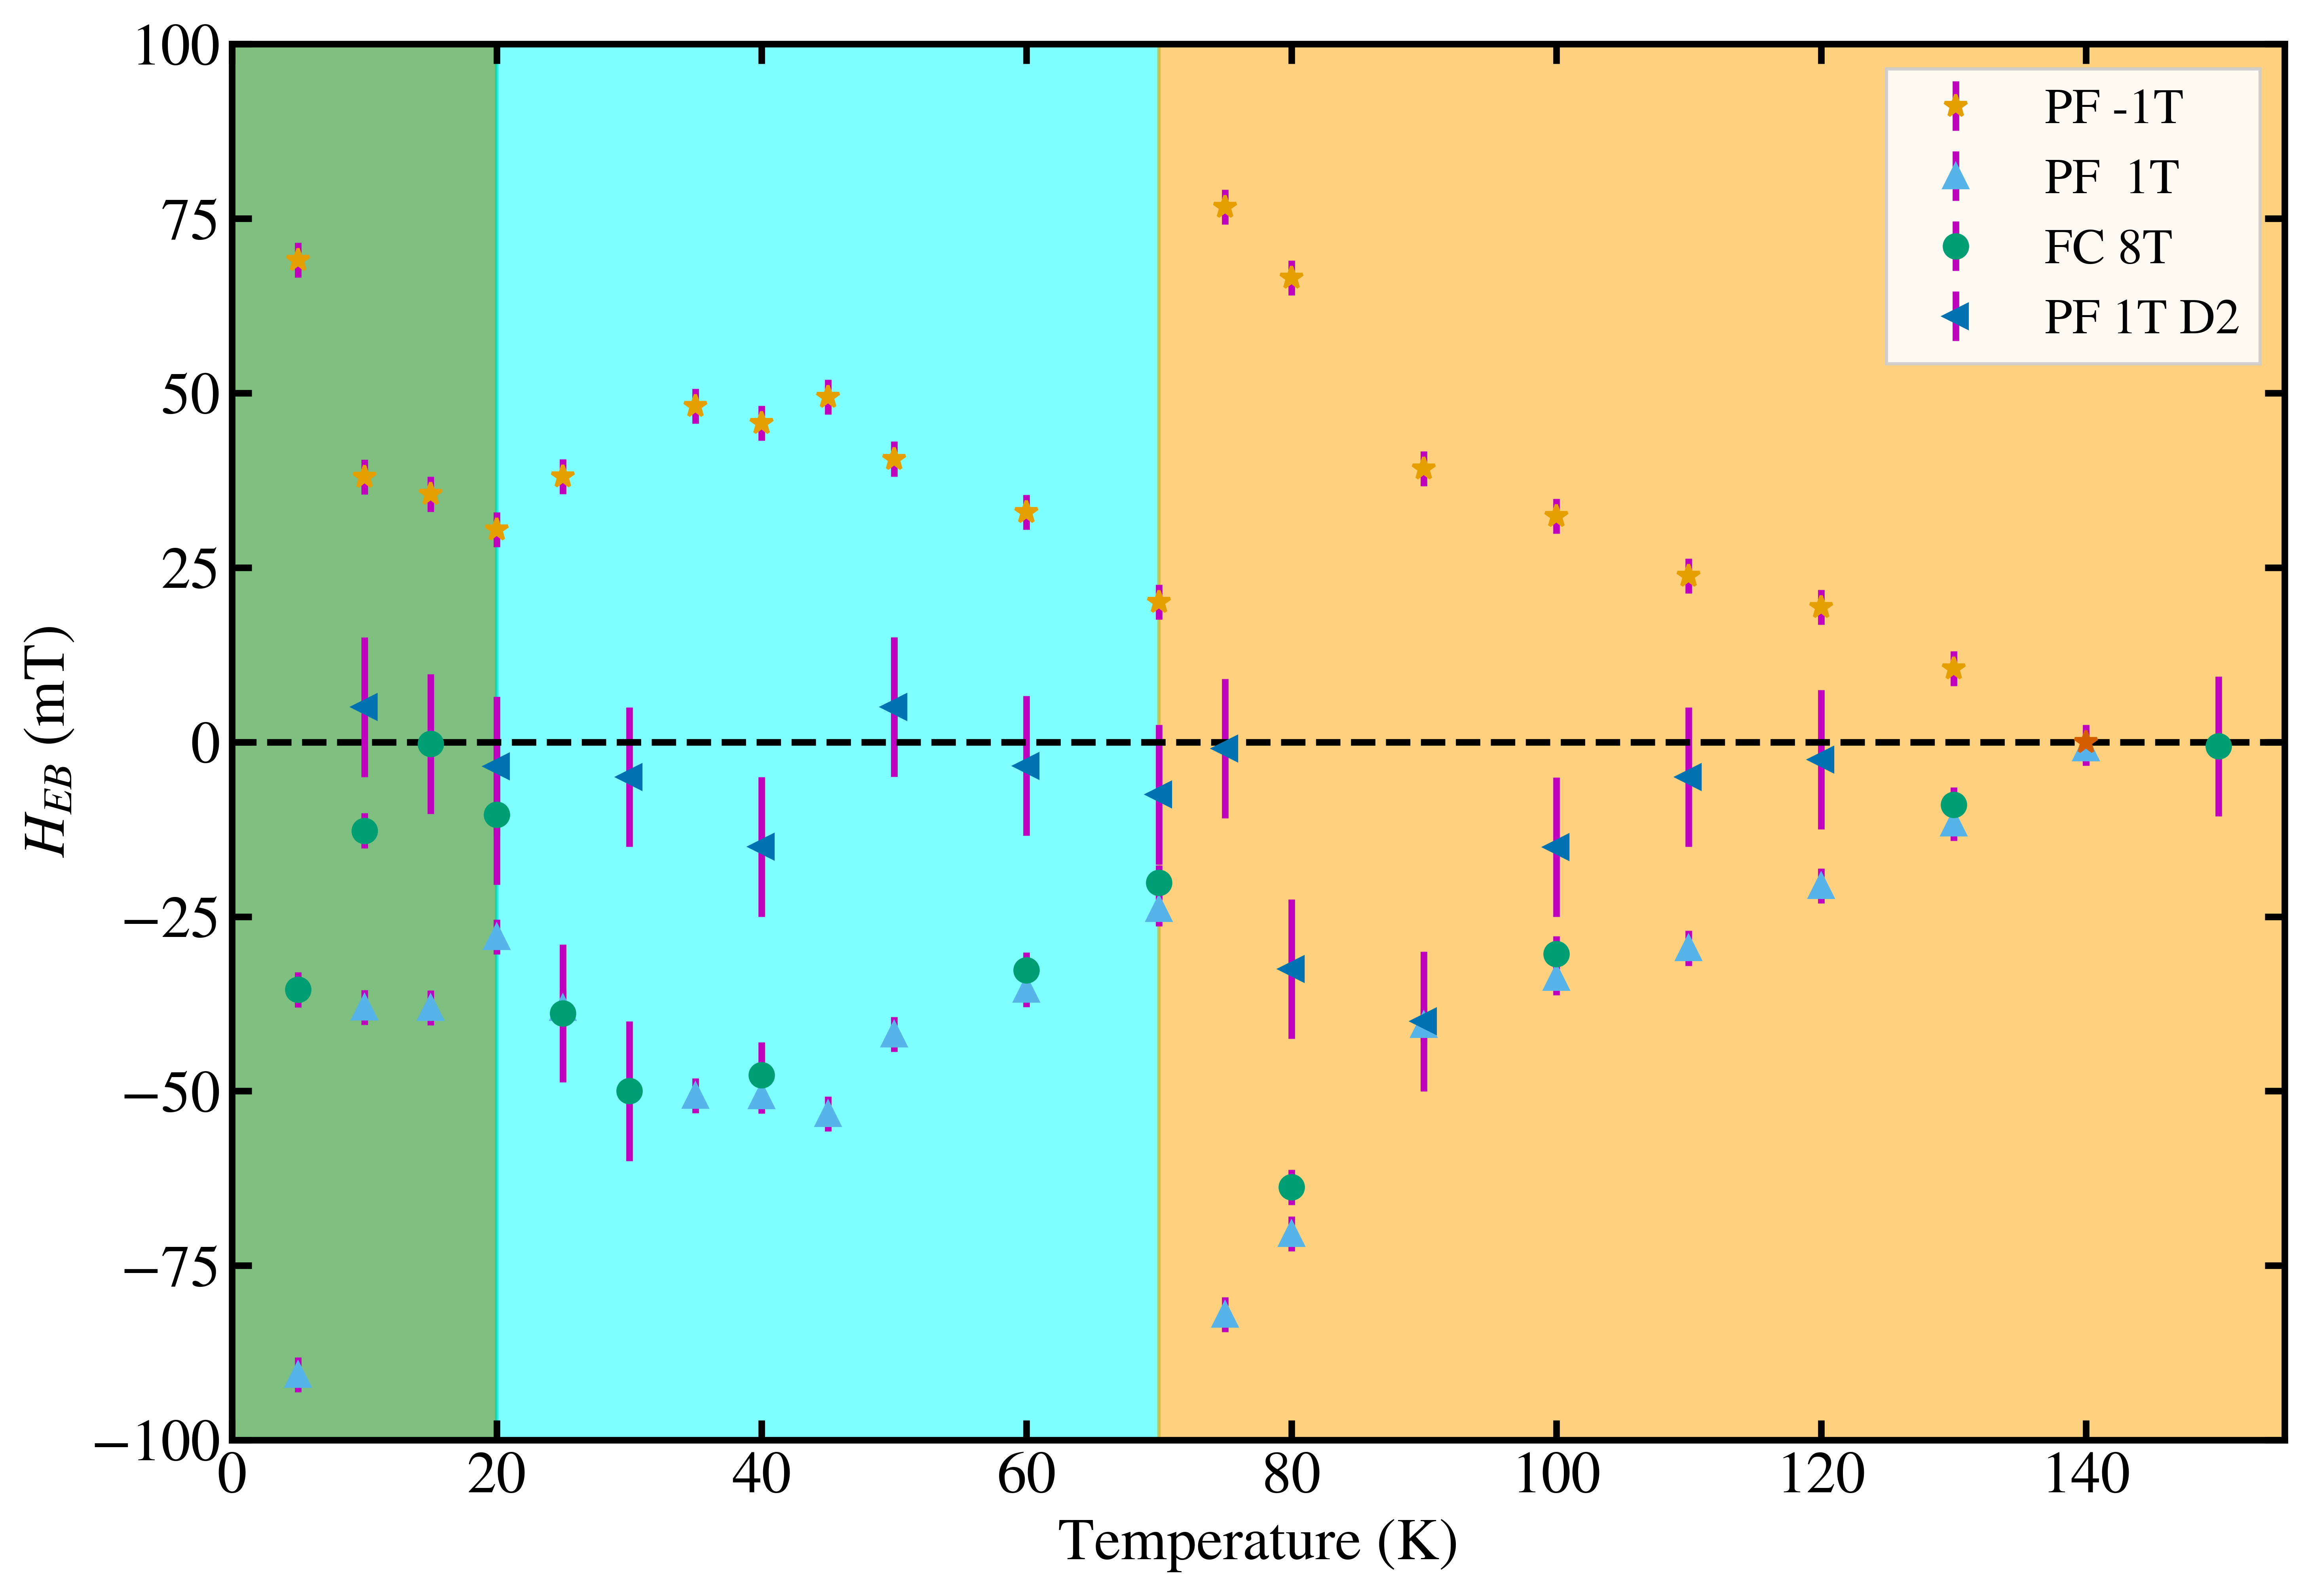

In [10]:
# All 4 series with fill_between regions
plt.figure(dpi=600)
plt.errorbar(res_pf['T_g'][posEB], res_pf['HEB'][posEB], 2.5, fmt='*', ecolor='m')
plt.errorbar(res_pf['T_g'][negEB], res_pf['HEB'][negEB], 2.5, fmt='^', ecolor='m')
plt.errorbar(TFC, EBFC, errFC, fmt='o', ecolor='m')
plt.errorbar(T_OFGT, H_OFGT, 10, fmt='<', ecolor='m')
plt.legend(['PF -1T', 'PF  1T', 'FC 8T', 'PF 1T D2'], fontsize=15)
plt.fill_between([0, 20],   [100, 100], [-100, -100], color='green',  alpha=0.5)
plt.fill_between([20, 70],  [100, 100], [-100, -100], color='cyan',   alpha=0.5)
plt.fill_between([70, 155], [100, 100], [-100, -100], color='orange', alpha=0.5)
plt.errorbar(140, 0, 2.5, fmt='*', ecolor='m')
plt.plot([0, 155], [0, 0], 'k--')
plt.xlabel('Temperature (K)', fontsize=18);  plt.ylabel('$H_{EB}$ (mT)', fontsize=18)
plt.ylim(-100, 100);  plt.xlim(0, 155)
plt.tight_layout();  plt.show()

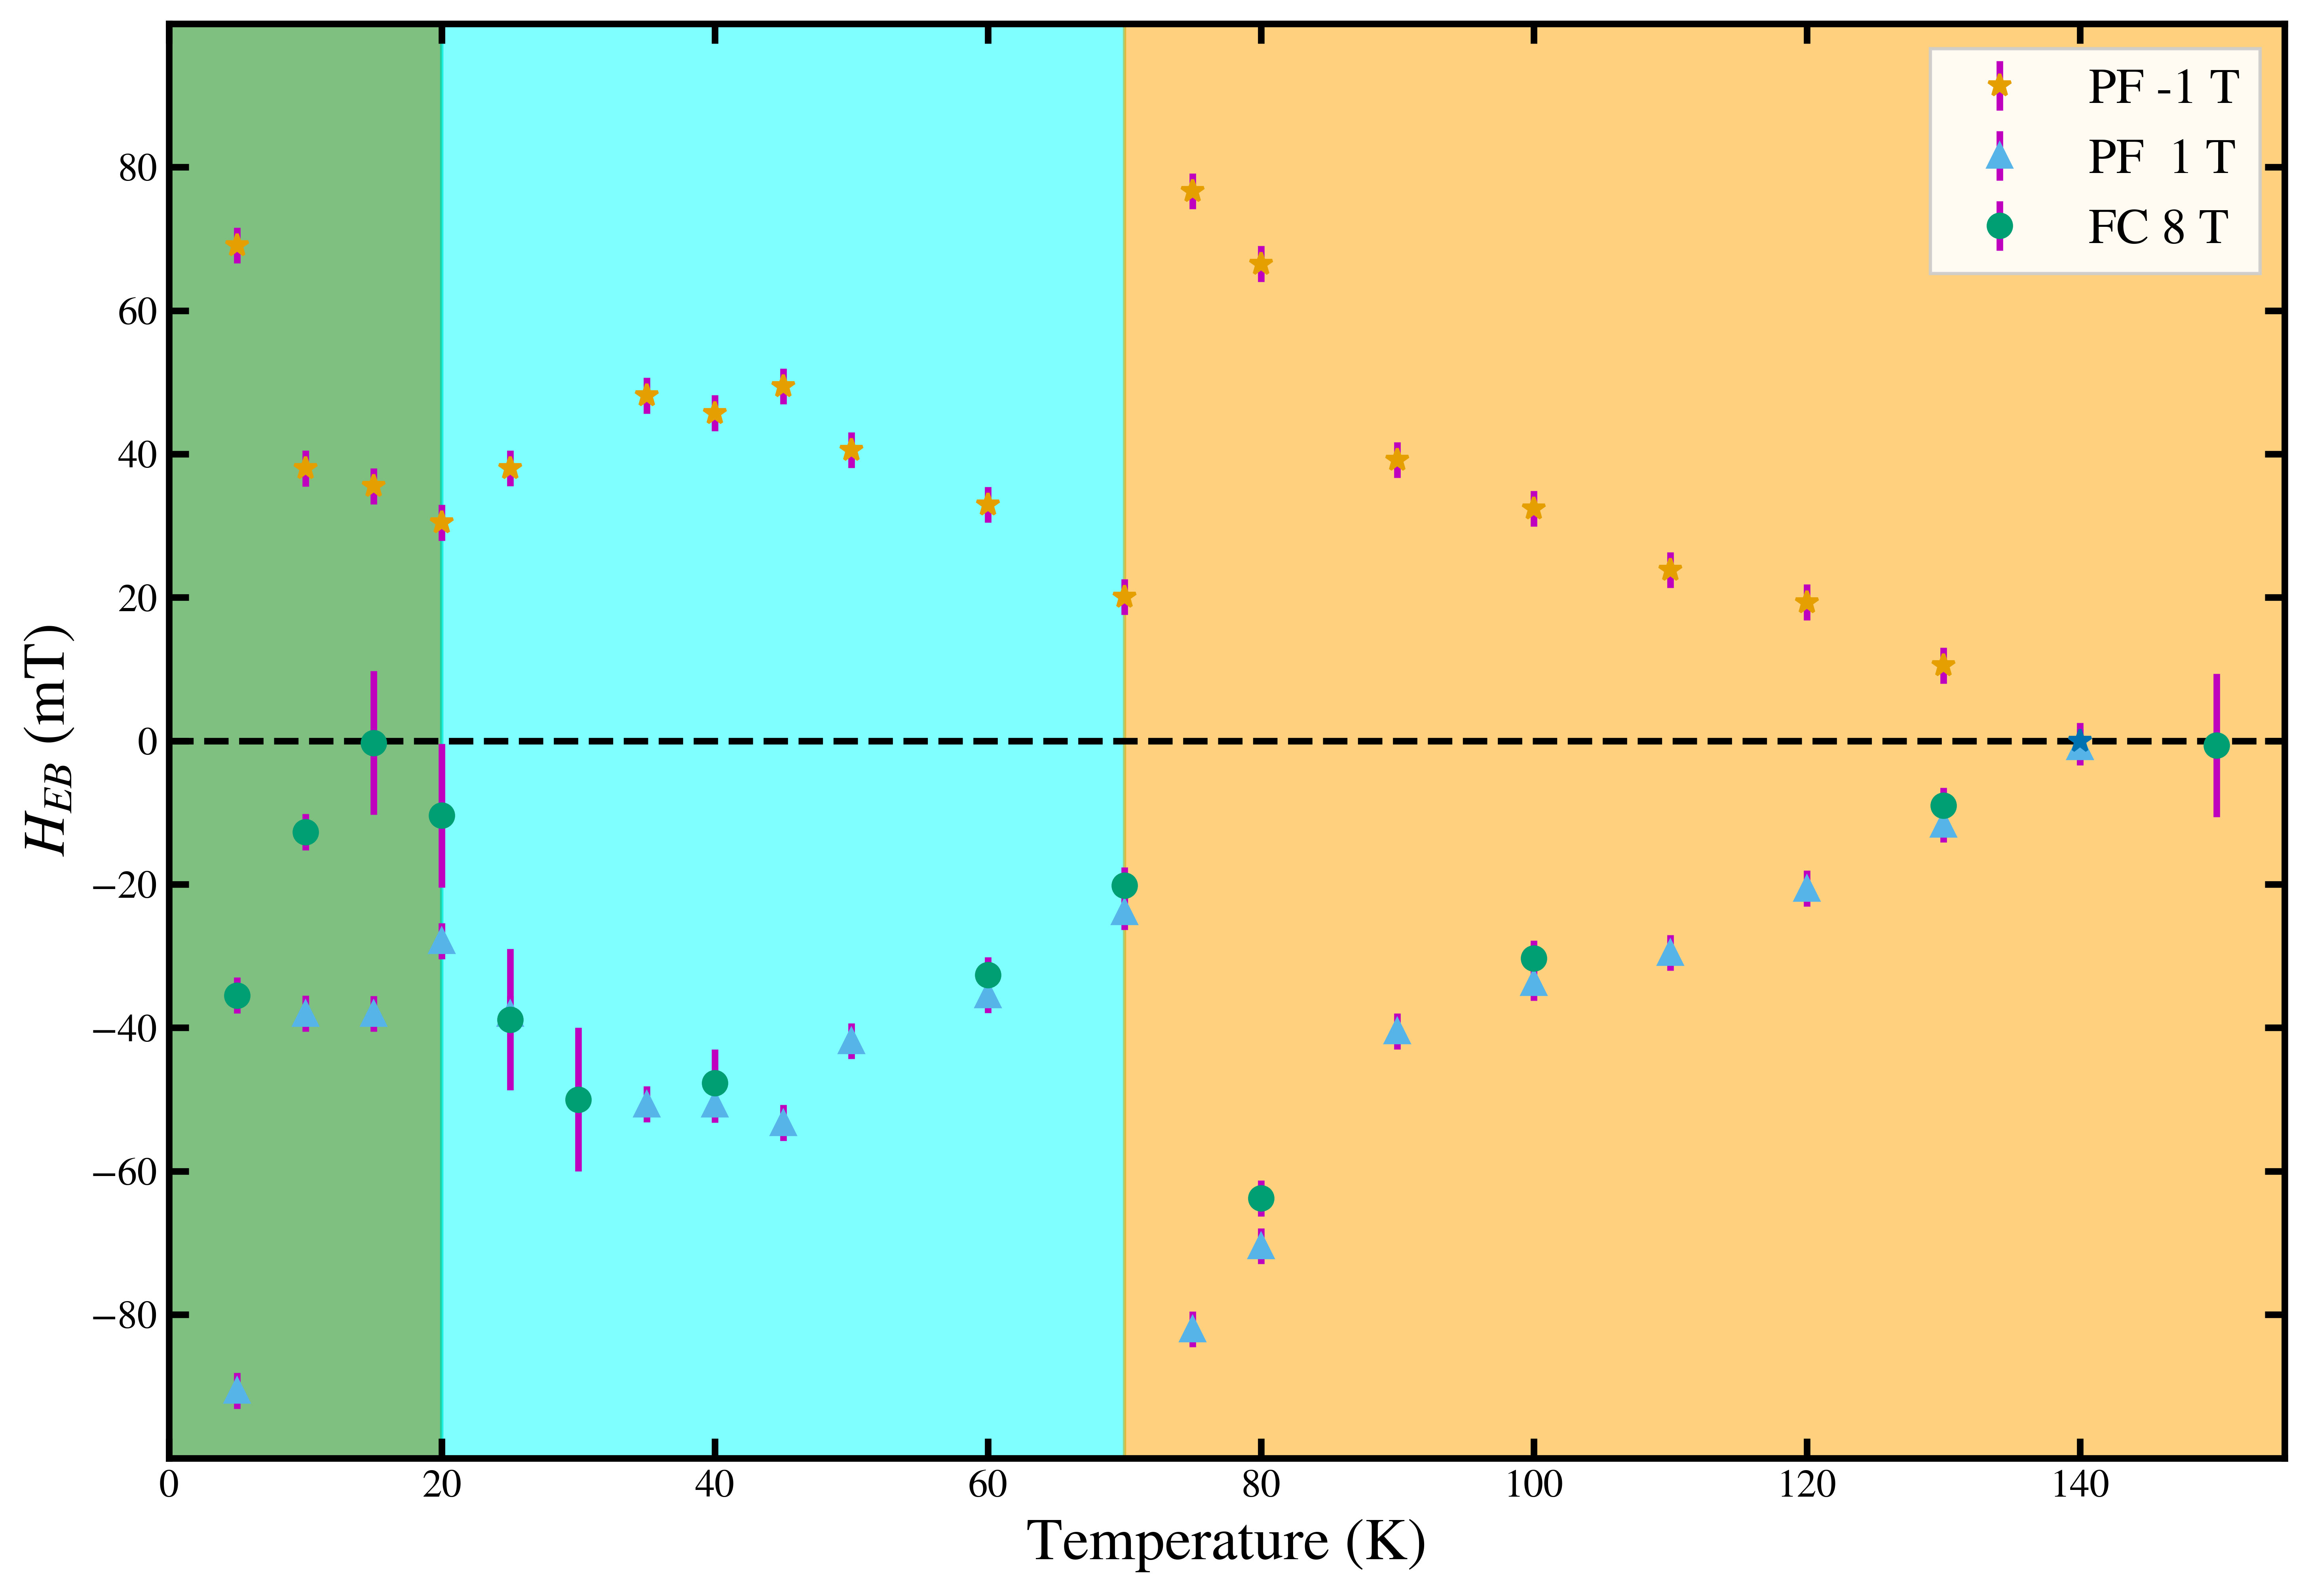

In [11]:
# 3 series without OFGT, with tick formatting
plt.figure(dpi=600)
plt.errorbar(res_pf['T_g'][posEB], res_pf['HEB'][posEB], 2.5, fmt='*', ecolor='m')
plt.errorbar(res_pf['T_g'][negEB], res_pf['HEB'][negEB], 2.5, fmt='^', ecolor='m')
plt.errorbar(TFC, EBFC, errFC, fmt='o', ecolor='m')
plt.legend(['PF -1 T', 'PF  1 T', 'FC 8 T'], fontsize=15)
plt.fill_between([0, 20],   [100, 100], [-100, -100], color='green',  alpha=0.5)
plt.fill_between([20, 70],  [100, 100], [-100, -100], color='cyan',   alpha=0.5)
plt.fill_between([70, 155], [100, 100], [-100, -100], color='orange', alpha=0.5)
plt.errorbar(140, 0, 2.5, fmt='*', ecolor='m')
plt.plot([0, 155], [0, 0], 'k--')
plt.xlabel('Temperature (K)', fontsize=18);  plt.ylabel('$H_{EB}$ (mT)', fontsize=18)
plt.ylim(-100, 100);  plt.xlim(0, 155)
plt.xticks([0, 20, 40, 60, 80, 100, 120, 140], fontsize=12)
plt.yticks([-80, -60, -40, -20, 0, 20, 40, 60, 80], fontsize=12)
plt.tight_layout();  plt.show()